# **Proposed Iterative Framework Experiments**

### Confidence Score based Threshold

###### Prediction on Unlabeled Training Set

In [ ]:
import gc
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

unlabeled_df = cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ].copy()

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
        }


best_deberta_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best").to(device)

best_deberta_model.eval()

tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-large")
unlabeled_ds = UnlabeledDataset(
    unlabeled_df['combined_input'].tolist(),
    tokenizer=tokenizer
)

unlabeled_loader = DataLoader(unlabeled_ds, batch_size=16, shuffle=False)
pred_confidences = []

with torch.no_grad():
    for batch in tqdm(unlabeled_loader, desc="Predicting on Unlabeled"):
        inputs = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        outputs = best_deberta_model(input_ids=inputs, attention_mask=masks)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].detach().cpu().numpy()
        pred_confidences.extend(probs)

unlabeled_df['pred_confidence'] = pred_confidences
unlabeled_df['pred_label'] = (unlabeled_df['pred_confidence'] > 0.5).astype(int)



Using device: cuda


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Predicting on Unlabeled: 100%|██████████| 3666/3666 [07:07<00:00,  8.58it/s]


In [ ]:
print(unlabeled_df.shape)
unlabeled_df.head()

(58649, 14)


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,pred_confidence,pred_label
0,Of or pertaining to the language of a particul...,"Of or pertaining to everyday language , as opp...","There are blacktips , silvertips , bronze whal...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,Of or pertaining to the language of a particul...,0.136157,0
1,Not coercive ; not involving coercion,Not coercive ; free of coercion,Mr. obama signed executive orders requiring al...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,Not coercive ; not involving coercion Mr. obam...,0.010164,0
2,To express or express by words ; to express by...,To depict or portray .,Disloyal ? / the word is too good to paint out...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,To express or express by words ; to express by...,0.045941,0
3,Having the power to authoritatively speak or w...,Having a commanding style .,"He instructed us in that booming , authoritati...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,Having the power to authoritatively speak or w...,0.020757,0
4,Without a scot .,"Without consequences or penalties , to go free...",To get off scot-free . What is the meaning of ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,Without a scot . To get off scot-free . What i...,0.036712,0


##### Threshold >=51% using DeBERTa model

<ipython-input-15-b5f47e6ece12>:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(average_probs_series)


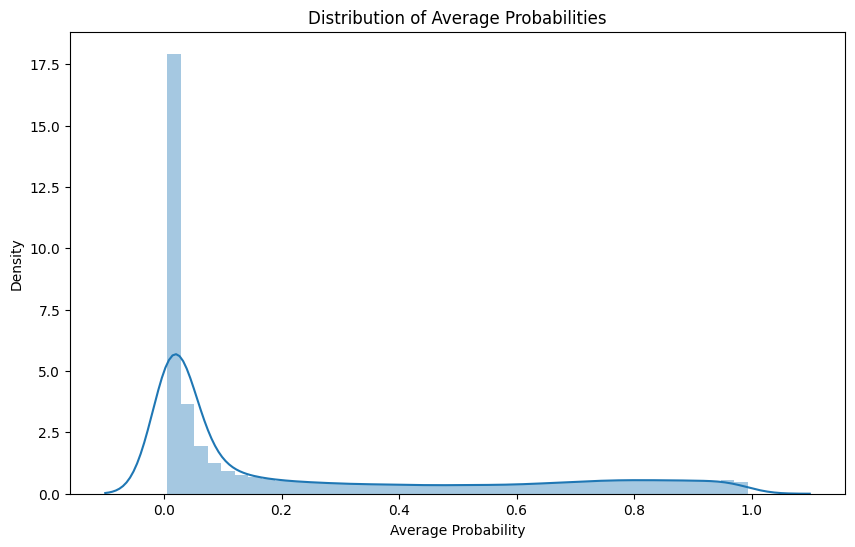

,Statistic,Value
0,Mean,0.246199
1,Median,0.053075
2,Max,0.993860
3,Min,0.005292
4,Count Above Mean,19526.000000
5,Count Below Mean,39123.000000
6,Count Above 50%,13858.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'average_probs' is a NumPy array as shown in the provided code
# Convert to pandas Series for easier stats calculation
average_probs_series = unlabeled_df['pred_confidence']


# Distribution Plot
plt.figure(figsize=(10, 6))
sns.distplot(average_probs_series)
plt.title('Distribution of Average Probabilities')
plt.xlabel('Average Probability')
plt.ylabel('Density')
plt.show()

# Calculate Statistics
mean_prob = average_probs_series.mean()
median_prob = average_probs_series.median()
max_prob = average_probs_series.max()
min_prob = average_probs_series.min()
above_mean_count = (average_probs_series > mean_prob).sum()
below_mean_count = (average_probs_series < mean_prob).sum()
above_50_count = (average_probs_series > 0.50).sum()

# Create a table
stats_table = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Max', 'Min', 'Count Above Mean', 'Count Below Mean', 'Count Above 50%'],
    'Value': [mean_prob, median_prob, max_prob, min_prob, above_mean_count, below_mean_count, above_50_count]
})

# Display the table
stats_table


In [ ]:
threshold = 0.51
selected_unlabeled = unlabeled_df[ unlabeled_df['pred_confidence'] >= threshold ].copy()

print(f"High-confidence unlabeled records: {len(selected_unlabeled)}")

labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

train_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

selected_unlabeled['label'] = selected_unlabeled['pred_label'].astype(int)

augmented_train_df = pd.concat([train_df, selected_unlabeled], ignore_index=True)
print(f"Size of labeled validation data: {len(train_df)}")
print(f"Augmented training set size: {len(augmented_train_df)}")

augmented_train_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/augmented_train_data.csv", index=False)

gc.collect()
torch.cuda.empty_cache()

print("Done. Next step: Re-train your DeBERTa model on 'augmented_train_df' + evaluate on test set.")

High-confidence unlabeled records: 13631
Size of labeled validation data: 1000
Augmented training set size: 14631
Done. Next step: Re-train your DeBERTa model on 'augmented_train_df' + evaluate on test set.


In [ ]:
print(test_df.shape)
test_df.head()

(2995, 12)


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input
59649,A crazy person .,Crazy person ; crackpot or lunatic .,"Sadly , at the end of his life , Luther became...",NaN,DM,NaN,Test (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",0,0.0,0.0,"A crazy person . Sadly , at the end of his lif..."
59650,Historians have strongly criticized the FBI's ...,Historians have criticized past FBI policies f...,इतिहासकार लोगन FBI के पिछला नीति के बहुत आलोचन...,NaN,MT,NaN,Test (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",0,0.0,4.0,Historians have strongly criticized the FBI's ...
59651,The eastern islands of the Indian Ocean are lo...,The East African Islands are in the Indian Oce...,Àwọn erekùsù ìlà oòrùn adúláwọ̀ wà ní òkun Ind...,NaN,MT,NaN,Test (Model-Aware),"['Not Hallucination', 'Hallucination', 'Halluc...",1,0.6,5.0,The eastern islands of the Indian Ocean are lo...
59652,"The social group of a person , especially a wo...",High society .,Smith was first introduced into society at the...,NaN,DM,NaN,Test (Model-Aware),"['Hallucination', 'Hallucination', 'Hallucinat...",1,1.0,9.0,"The social group of a person , especially a wo..."
59653,It uses a giant rocket over 100 feet high to l...,It takes a giant rocket over a 100 feet high t...,Ngini mamakai roket raksasa malabihi 100 kaki ...,NaN,MT,NaN,Test (Model-Aware),"['Hallucination', 'Not Hallucination', 'Not Ha...",0,0.4,11.0,It uses a giant rocket over 100 feet high to l...


Augmented train samples: 14631
Test samples: 2995


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.1700


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 42: 100%|██████████| 1828/1828 [06:32<00:00,  4.66it/s]


Epoch 2 completed. Avg Loss: 0.1681


Finetuning microsoft/deberta-v3-large - Epoch 3, Seed 42: 100%|██████████| 1828/1828 [06:33<00:00,  4.65it/s]


Epoch 3 completed. Avg Loss: 0.1674


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 42 - Test Accuracy: 0.3876, Spearman: 0.0117
Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1834
           1     0.3876    1.0000    0.5587      1161

    accuracy                         0.3876      2995
   macro avg     0.1938    0.5000    0.2794      2995
weighted avg     0.1503    0.3876    0.2166      2995

Confusion Matrix:
 [[   0 1834]
 [   0 1161]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


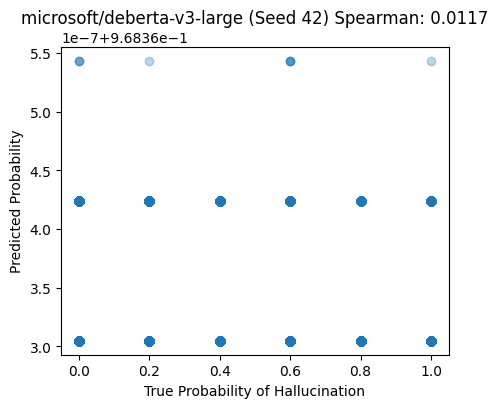

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.1692


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 52: 100%|██████████| 1828/1828 [06:34<00:00,  4.63it/s]


Epoch 2 completed. Avg Loss: 0.1680


Finetuning microsoft/deberta-v3-large - Epoch 3, Seed 52: 100%|██████████| 1828/1828 [06:34<00:00,  4.63it/s]


Epoch 3 completed. Avg Loss: 0.1676


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 52 - Test Accuracy: 0.3876, Spearman: nan
Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1834
           1     0.3876    1.0000    0.5587      1161

    accuracy                         0.3876      2995
   macro avg     0.1938    0.5000    0.2794      2995
weighted avg     0.1503    0.3876    0.2166      2995

Confusion Matrix:
 [[   0 1834]
 [   0 1161]]


<ipython-input-22-52dfc521c3d6>:187: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp_corr, _ = spearmanr(test_true_probs, test_probs)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa

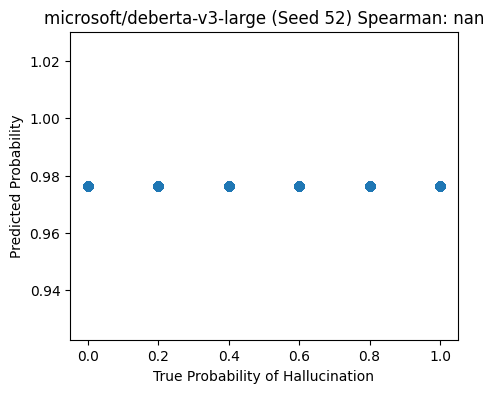

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.1353


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 62: 100%|██████████| 1828/1828 [06:34<00:00,  4.63it/s]


Epoch 2 completed. Avg Loss: 0.0853


Finetuning microsoft/deberta-v3-large - Epoch 3, Seed 62: 100%|██████████| 1828/1828 [06:34<00:00,  4.63it/s]


Epoch 3 completed. Avg Loss: 0.0505


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 62 - Test Accuracy: 0.6250, Spearman: 0.5277
Classification Report:
               precision    recall  f1-score   support

           0     0.8715    0.4547    0.5976      1834
           1     0.5093    0.8941    0.6490      1161

    accuracy                         0.6250      2995
   macro avg     0.6904    0.6744    0.6233      2995
weighted avg     0.7311    0.6250    0.6175      2995

Confusion Matrix:
 [[ 834 1000]
 [ 123 1038]]


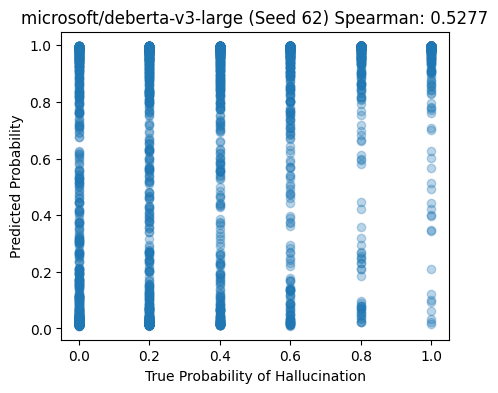


Final Aggregated Results over 3 seeds:
Accuracy: 0.4668 ± 0.1119
Spearman Corr: nan ± nan


In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm


augmented_df = pd.read_csv("augmented_train_data.csv")  # Combined val + newly labeled high-confidence
print(f"Augmented train samples: {len(augmented_df)}")

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]
X_test = test_df['combined_input'].tolist()
y_test = test_df['label'].tolist()
p_test = test_df['p(Hallucination)'].tolist()  # For Spearman correlation

print(f"Test samples: {len(test_df)}")

class FinalTrainDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):

        if 'p(Hallucination)' in df.columns:
            self.probs = df['p(Hallucination)'].fillna(0).tolist()
        else:
            self.probs = [0]*len(df)

        self.texts = df['combined_input'].tolist()
        self.labels = df['label'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }

class FinalTestDataset(Dataset):
    def __init__(self, texts, labels, probs, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.probs = probs
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }


def final_train_and_evaluate_deberta(model_name,
                                     train_df_path="augmented_train_data.csv",
                                     lr=2e-5,
                                     batch_size=8,
                                     epochs=3,
                                     seeds=[42,52,62]):

    acc_scores, spearman_scores = [], []
    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Load augmented train data
        train_aug_df = pd.read_csv(train_df_path)
        train_dataset = FinalTrainDataset(train_aug_df, tokenizer=tokenizer)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
        optimizer = AdamW(model.parameters(), lr=lr)

        # Train
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch in tqdm(train_loader, desc=f"Finetuning {model_name} - Epoch {epoch+1}, Seed {seed}"):
                optimizer.zero_grad()
                outputs = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                    labels=batch['label'].to(device)
                )
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            print(f"Epoch {epoch+1} completed. Avg Loss: {total_loss/len(train_loader):.4f}")
            gc.collect()
            torch.cuda.empty_cache()

        # Final evaluation on Test Set
        test_tokenizer = AutoTokenizer.from_pretrained(model_name)
        test_dataset = FinalTestDataset(X_test, y_test, p_test, test_tokenizer)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model.eval()
        test_preds, test_probs, test_true_labels, test_true_probs = [], [], [], []
        with torch.no_grad():
            for batch in test_loader:
                out = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                )
                logits = out.logits
                prob_batch = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                pred_batch = (prob_batch > 0.5).astype(int)

                test_probs.extend(prob_batch)
                test_preds.extend(pred_batch)
                test_true_labels.extend(batch['label'].cpu().numpy())
                test_true_probs.extend(batch['prob'].cpu().numpy())

        acc = accuracy_score(test_true_labels, test_preds)
        sp_corr, _ = spearmanr(test_true_probs, test_probs)
        acc_scores.append(acc)
        spearman_scores.append(sp_corr)

        print(f"\nSeed {seed} - Test Accuracy: {acc:.4f}, Spearman: {sp_corr:.4f}")
        cls_report = classification_report(test_true_labels, test_preds, digits=4)
        print("Classification Report:\n", cls_report)
        cm = confusion_matrix(test_true_labels, test_preds)
        print("Confusion Matrix:\n", cm)

        # Spearman scatter plot
        plt.figure(figsize=(5, 4))
        plt.scatter(test_true_probs, test_probs, alpha=0.3)
        plt.title(f"{model_name} (Seed {seed}) Spearman: {sp_corr:.4f}")
        plt.xlabel("True Probability of Hallucination")
        plt.ylabel("Predicted Probability")
        plt.show()

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"\nFinal Aggregated Results over {len(seeds)} seeds:")
    print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    print(f"Spearman Corr: {np.mean(spearman_scores):.4f} ± {np.std(spearman_scores):.4f}")


final_train_and_evaluate_deberta(
    model_name="microsoft/deberta-v3-large",
    train_df_path="augmented_train_data.csv",
    lr=2e-5,
    batch_size=8,
    epochs=3,
    seeds=[42, 52, 62]
)


##### Threshold >=90% using DeBERTa model

<ipython-input-28-2b00fdcc42fb>:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(average_probs_series)


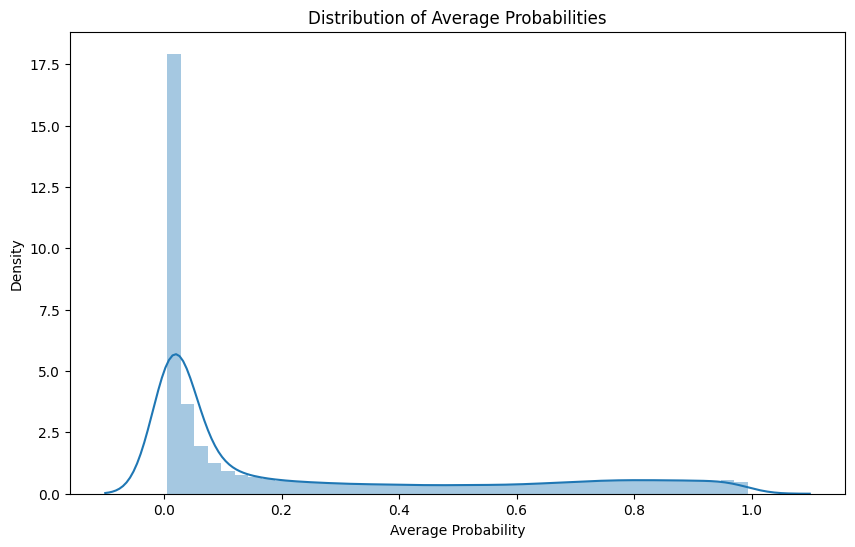

,Statistic,Value
0,Mean,0.246199
1,Median,0.053075
2,Max,0.993860
3,Min,0.005292
4,Count Above Mean,19526.000000
5,Count Below Mean,39123.000000
6,Count Above 90%,2875.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


average_probs_series = unlabeled_df['pred_confidence']


# Distribution Plot
plt.figure(figsize=(10, 6))
sns.distplot(average_probs_series)
plt.title('Distribution of Average Probabilities')
plt.xlabel('Average Probability')
plt.ylabel('Density')
plt.show()

# Calculate Statistics
mean_prob = average_probs_series.mean()
median_prob = average_probs_series.median()
max_prob = average_probs_series.max()
min_prob = average_probs_series.min()
above_mean_count = (average_probs_series > mean_prob).sum()
below_mean_count = (average_probs_series < mean_prob).sum()
above_90_count = (average_probs_series > 0.90).sum()

# Create a table
stats_table = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Max', 'Min', 'Count Above Mean', 'Count Below Mean', 'Count Above 90%'],
    'Value': [mean_prob, median_prob, max_prob, min_prob, above_mean_count, below_mean_count, above_90_count]
})

# Display the table
stats_table


In [ ]:
threshold = 0.90
selected_unlabeled = unlabeled_df[ unlabeled_df['pred_confidence'] >= threshold ].copy()

print(f"High-confidence unlabeled records: {len(selected_unlabeled)}")

labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

train_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

selected_unlabeled['label'] = selected_unlabeled['pred_label'].astype(int)

augmented_train_df = pd.concat([train_df, selected_unlabeled], ignore_index=True)
print(f"Size of labeled validation data: {len(train_df)}")
print(f"Augmented training set size: {len(augmented_train_df)}")

# Save or keep in memory for next step of re-training
augmented_train_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/augmented_train_data_90.csv", index=False)

gc.collect()
torch.cuda.empty_cache()

print("Done. Next step: Re-train your DeBERTa model on 'augmented_train_df' + evaluate on test set.")

High-confidence unlabeled records: 2875
Size of labeled validation data: 1000
Augmented training set size: 3875
Done. Next step: Re-train your DeBERTa model on 'augmented_train_df' + evaluate on test set.


Augmented train samples: 3875
Test samples: 2995


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.4272


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 42: 100%|██████████| 484/484 [01:44<00:00,  4.63it/s]


Epoch 2 completed. Avg Loss: 0.4263


Finetuning microsoft/deberta-v3-large - Epoch 3, Seed 42: 100%|██████████| 484/484 [01:44<00:00,  4.63it/s]


Epoch 3 completed. Avg Loss: 0.4249


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 42 - Test Accuracy: 0.3876, Spearman: 0.2937
Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1834
           1     0.3876    1.0000    0.5587      1161

    accuracy                         0.3876      2995
   macro avg     0.1938    0.5000    0.2794      2995
weighted avg     0.1503    0.3876    0.2166      2995

Confusion Matrix:
 [[   0 1834]
 [   0 1161]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


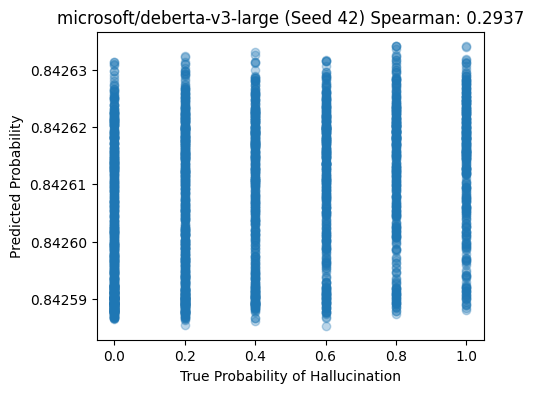

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.2736


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 52: 100%|██████████| 484/484 [01:44<00:00,  4.64it/s]


Epoch 2 completed. Avg Loss: 0.1181


Finetuning microsoft/deberta-v3-large - Epoch 3, Seed 52: 100%|██████████| 484/484 [01:44<00:00,  4.64it/s]


Epoch 3 completed. Avg Loss: 0.0538


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 52 - Test Accuracy: 0.7316, Spearman: 0.6109
Classification Report:
               precision    recall  f1-score   support

           0     0.8499    0.6821    0.7568      1834
           1     0.6172    0.8096    0.7004      1161

    accuracy                         0.7316      2995
   macro avg     0.7335    0.7459    0.7286      2995
weighted avg     0.7597    0.7316    0.7350      2995

Confusion Matrix:
 [[1251  583]
 [ 221  940]]


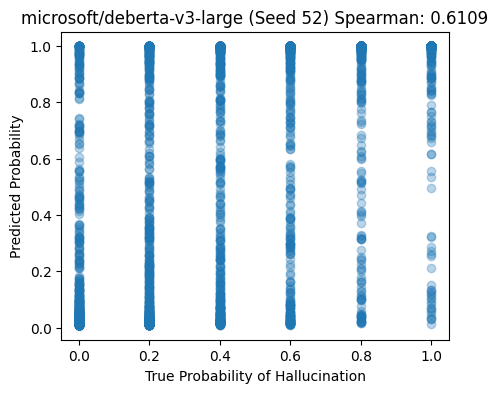

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.2737


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 62: 100%|██████████| 484/484 [01:44<00:00,  4.64it/s]


Epoch 2 completed. Avg Loss: 0.1138


Finetuning microsoft/deberta-v3-large - Epoch 3, Seed 62: 100%|██████████| 484/484 [01:44<00:00,  4.63it/s]


Epoch 3 completed. Avg Loss: 0.0494


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 62 - Test Accuracy: 0.7362, Spearman: 0.6417
Classification Report:
               precision    recall  f1-score   support

           0     0.8551    0.6854    0.7609      1834
           1     0.6216    0.8165    0.7059      1161

    accuracy                         0.7362      2995
   macro avg     0.7384    0.7510    0.7334      2995
weighted avg     0.7646    0.7362    0.7396      2995

Confusion Matrix:
 [[1257  577]
 [ 213  948]]


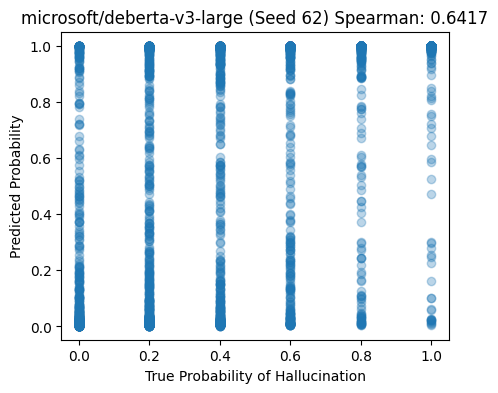


Final Aggregated Results over 3 seeds:
Accuracy: 0.6185 ± 0.1632
Spearman Corr: 0.5155 ± 0.1573


In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm


augmented_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/augmented_train_data_90.csv")  # Combined val + newly labeled high-confidence
print(f"Augmented train samples: {len(augmented_df)}")



# labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
# labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

# if 'p(Hallucination)' not in labeled_df.columns:
#     raise ValueError("Missing `p(Hallucination)` field in dataset. Ensure probability values exist.")

# labeled_df['combined_input'] = (
#     labeled_df['hyp'].fillna('') + ' ' +
#     labeled_df['src'].fillna('') + ' ' +
#     labeled_df['tgt'].fillna('') + ' ' +
#     labeled_df['ref'].fillna('') + ' ' +
#     labeled_df['model'].fillna('') + ' ' +
#     labeled_df['task'].fillna('')
# )

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]
X_test = test_df['combined_input'].tolist()
y_test = test_df['label'].tolist()
p_test = test_df['p(Hallucination)'].tolist()  # For Spearman correlation

print(f"Test samples: {len(test_df)}")


class FinalTrainDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):

        if 'p(Hallucination)' in df.columns:
            self.probs = df['p(Hallucination)'].fillna(0).tolist()
        else:
            self.probs = [0]*len(df)

        self.texts = df['combined_input'].tolist()
        self.labels = df['label'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }

class FinalTestDataset(Dataset):
    def __init__(self, texts, labels, probs, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.probs = probs
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }


def final_train_and_evaluate_deberta(model_name,
                                     train_df_path="/content/drive/MyDrive/SHROOM-Dataset/augmented_train_data_90.csv",
                                     lr=2e-5,
                                     batch_size=8,
                                     epochs=3,
                                     seeds=[42,52,62]):

    acc_scores, spearman_scores = [], []
    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Load augmented train data
        train_aug_df = pd.read_csv(train_df_path)
        train_dataset = FinalTrainDataset(train_aug_df, tokenizer=tokenizer)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
        optimizer = AdamW(model.parameters(), lr=lr)

        # Train
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch in tqdm(train_loader, desc=f"Finetuning {model_name} - Epoch {epoch+1}, Seed {seed}"):
                optimizer.zero_grad()
                outputs = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                    labels=batch['label'].to(device)
                )
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            print(f"Epoch {epoch+1} completed. Avg Loss: {total_loss/len(train_loader):.4f}")
            gc.collect()
            torch.cuda.empty_cache()

        # Final evaluation on Test Set
        test_tokenizer = AutoTokenizer.from_pretrained(model_name)
        test_dataset = FinalTestDataset(X_test, y_test, p_test, test_tokenizer)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model.eval()
        test_preds, test_probs, test_true_labels, test_true_probs = [], [], [], []
        with torch.no_grad():
            for batch in test_loader:
                out = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                )
                logits = out.logits
                prob_batch = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                pred_batch = (prob_batch > 0.5).astype(int)

                test_probs.extend(prob_batch)
                test_preds.extend(pred_batch)
                test_true_labels.extend(batch['label'].cpu().numpy())
                test_true_probs.extend(batch['prob'].cpu().numpy())

        acc = accuracy_score(test_true_labels, test_preds)
        sp_corr, _ = spearmanr(test_true_probs, test_probs)
        acc_scores.append(acc)
        spearman_scores.append(sp_corr)

        print(f"\nSeed {seed} - Test Accuracy: {acc:.4f}, Spearman: {sp_corr:.4f}")
        cls_report = classification_report(test_true_labels, test_preds, digits=4)
        print("Classification Report:\n", cls_report)
        cm = confusion_matrix(test_true_labels, test_preds)
        print("Confusion Matrix:\n", cm)

        # Spearman scatter plot
        plt.figure(figsize=(5, 4))
        plt.scatter(test_true_probs, test_probs, alpha=0.3)
        plt.title(f"{model_name} (Seed {seed}) Spearman: {sp_corr:.4f}")
        plt.xlabel("True Probability of Hallucination")
        plt.ylabel("Predicted Probability")
        plt.show()

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"\nFinal Aggregated Results over {len(seeds)} seeds:")
    print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    print(f"Spearman Corr: {np.mean(spearman_scores):.4f} ± {np.std(spearman_scores):.4f}")


final_train_and_evaluate_deberta(
    model_name="microsoft/deberta-v3-large",
    train_df_path="/content/drive/MyDrive/SHROOM-Dataset/augmented_train_data_90.csv",
    lr=2e-5,
    batch_size=8,
    epochs=3,
    seeds=[42, 52, 62]
)


##### Threshold >=95% using DeBERTa model

<ipython-input-45-168b6557e0e1>:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(average_probs_series)


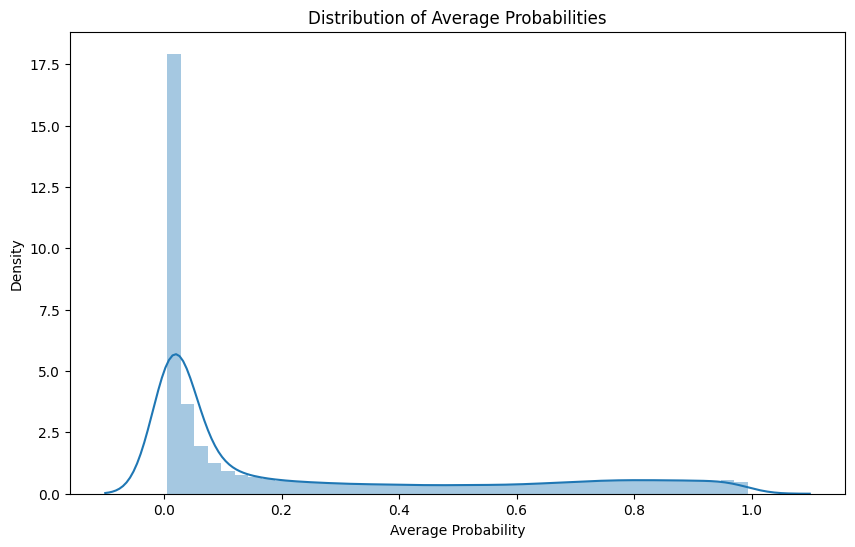

,Statistic,Value
0,Mean,0.246199
1,Median,0.053075
2,Max,0.993860
3,Min,0.005292
4,Count Above Mean,19526.000000
5,Count Below Mean,39123.000000
6,Count Above 95%,1373.000000
7,Count Below 20%,37760.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

average_probs_series = unlabeled_df['pred_confidence']

# Distribution Plot
plt.figure(figsize=(10, 6))
sns.distplot(average_probs_series)
plt.title('Distribution of Average Probabilities')
plt.xlabel('Average Probability')
plt.ylabel('Density')
plt.show()

# Calculate Statistics
mean_prob = average_probs_series.mean()
median_prob = average_probs_series.median()
max_prob = average_probs_series.max()
min_prob = average_probs_series.min()
above_mean_count = (average_probs_series > mean_prob).sum()
below_mean_count = (average_probs_series < mean_prob).sum()
above_95_count = (average_probs_series > 0.95).sum()
below_20_count = (average_probs_series < 0.2).sum()

# Create a table
stats_table = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Max', 'Min', 'Count Above Mean', 'Count Below Mean', 'Count Above 95%', 'Count Below 20%'],
    'Value': [mean_prob, median_prob, max_prob, min_prob, above_mean_count, below_mean_count, above_95_count,below_20_count]
})

# Display the table
stats_table


In [ ]:
##################################################
# STEP 7: FILTER RECORDS ABOVE A THRESHOLD
##################################################
threshold = 0.95  # Adjust as needed
selected_unlabeled = unlabeled_df[ unlabeled_df['pred_confidence'] >= threshold ].copy()

print(f"High-confidence unlabeled records: {len(selected_unlabeled)}")

##################################################
# STEP 8: COMBINE WITH ORIGINAL VALIDATION SET
##################################################
# NOTE: Your original validation set is 'train_df' (val-based training).
# We'll create a new DF that merges:
#   - label=pred_label from the model for newly-labeled data
#   - record fields from unlabeled
#   - plus the original labeled validation set
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

train_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

selected_unlabeled['label'] = selected_unlabeled['pred_label'].astype(int)

augmented_train_df = pd.concat([train_df, selected_unlabeled], ignore_index=True)
print(f"Size of labeled validation data: {len(train_df)}")
print(f"Augmented training set size: {len(augmented_train_df)}")

# Save or keep in memory for next step of re-training
augmented_train_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/augmented95.csv", index=False)

gc.collect()
torch.cuda.empty_cache()

print("Done. Next step: Re-train your DeBERTa model on 'augmented_train_df' + evaluate on test set.")

High-confidence unlabeled records: 1373
Size of labeled validation data: 1000
Augmented training set size: 2373
Done. Next step: Re-train your DeBERTa model on 'augmented_train_df' + evaluate on test set.


Augmented train samples: 2373
Test samples: 2995


/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 1, Seed 42: 100%|██████████| 296/296 [01:03<00:00,  4.63it/s]


Epoch 1 completed. Avg Loss: 0.0685


Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 2, Seed 42: 100%|██████████| 296/296 [01:03<00:00,  4.64it/s]


Epoch 2 completed. Avg Loss: 0.0555


Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 3, Seed 42: 100%|██████████| 296/296 [01:03<00:00,  4.64it/s]


Epoch 3 completed. Avg Loss: 0.0322

Seed 42 - Test Accuracy: 0.7599, Spearman: 0.6272
Classification Report:
               precision    recall  f1-score   support

           0     0.7689    0.8691    0.8160      1834
           1     0.7397    0.5874    0.6548      1161

    accuracy                         0.7599      2995
   macro avg     0.7543    0.7283    0.7354      2995
weighted avg     0.7576    0.7599    0.7535      2995

Confusion Matrix:
 [[1594  240]
 [ 479  682]]


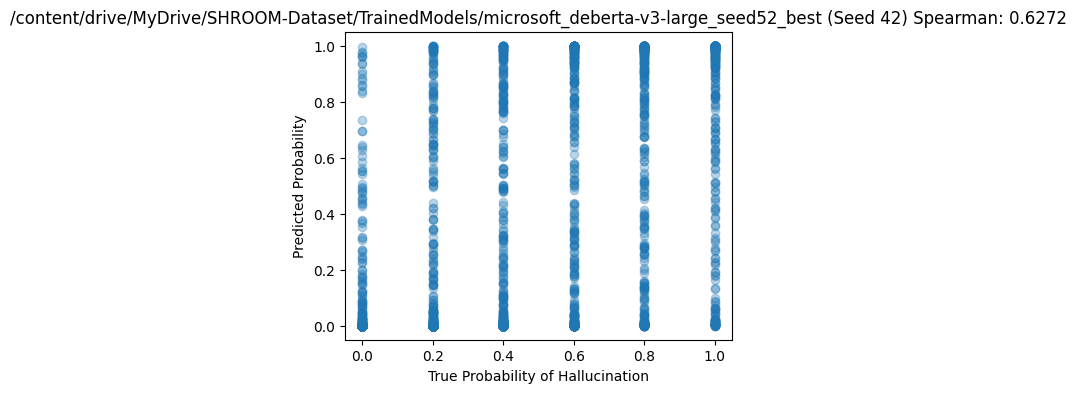

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 1, Seed 52: 100%|██████████| 296/296 [01:04<00:00,  4.62it/s]


Epoch 1 completed. Avg Loss: 0.1044


Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 2, Seed 52: 100%|██████████| 296/296 [01:04<00:00,  4.62it/s]


Epoch 2 completed. Avg Loss: 0.0441


Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 3, Seed 52: 100%|██████████| 296/296 [01:04<00:00,  4.62it/s]


Epoch 3 completed. Avg Loss: 0.0392

Seed 52 - Test Accuracy: 0.7539, Spearman: 0.6197
Classification Report:
               precision    recall  f1-score   support

           0     0.7454    0.9084    0.8189      1834
           1     0.7789    0.5099    0.6163      1161

    accuracy                         0.7539      2995
   macro avg     0.7622    0.7092    0.7176      2995
weighted avg     0.7584    0.7539    0.7404      2995

Confusion Matrix:
 [[1666  168]
 [ 569  592]]


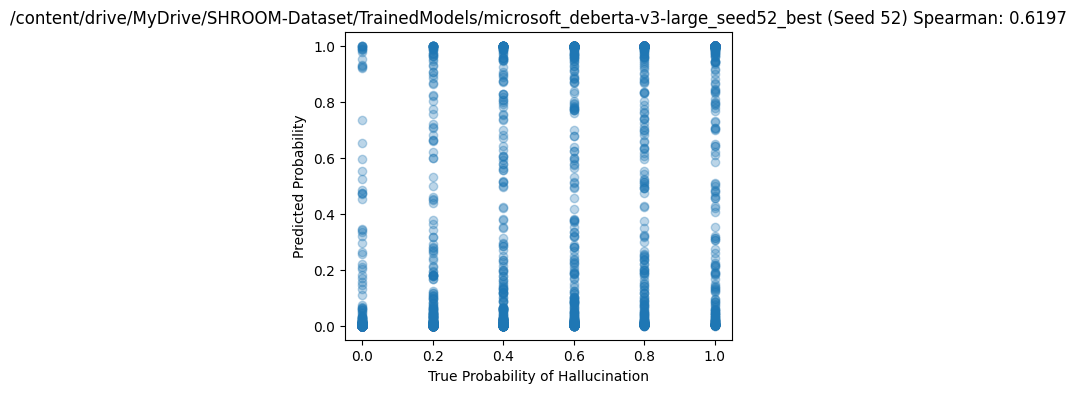

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 1, Seed 62: 100%|██████████| 296/296 [01:04<00:00,  4.60it/s]


Epoch 1 completed. Avg Loss: 0.0925


Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 2, Seed 62: 100%|██████████| 296/296 [01:04<00:00,  4.61it/s]


Epoch 2 completed. Avg Loss: 0.0745


Finetuning /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best - Epoch 3, Seed 62: 100%|██████████| 296/296 [01:04<00:00,  4.60it/s]


Epoch 3 completed. Avg Loss: 0.0199

Seed 62 - Test Accuracy: 0.7663, Spearman: 0.6321
Classification Report:
               precision    recall  f1-score   support

           0     0.7896    0.8430    0.8154      1834
           1     0.7223    0.6451    0.6815      1161

    accuracy                         0.7663      2995
   macro avg     0.7559    0.7440    0.7485      2995
weighted avg     0.7635    0.7663    0.7635      2995

Confusion Matrix:
 [[1546  288]
 [ 412  749]]


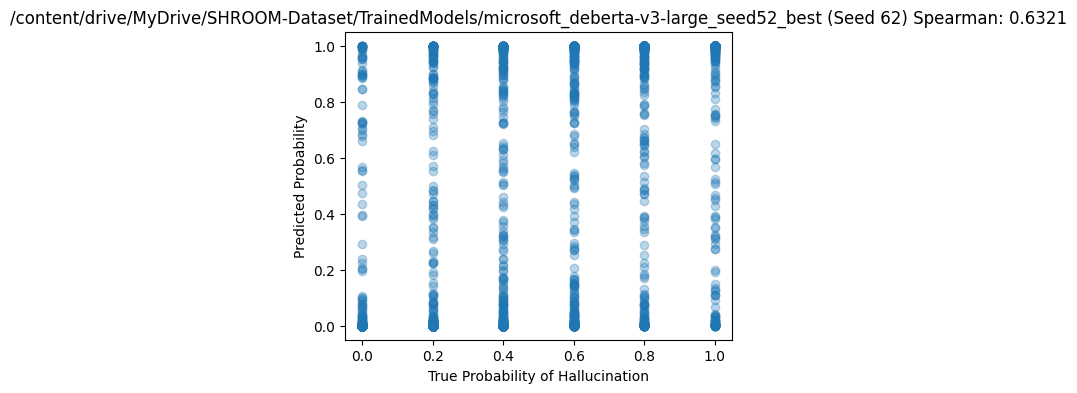


Final Aggregated Results over 3 seeds:
Accuracy: 0.7600 ± 0.0050
Spearman Corr: 0.6264 ± 0.0051


In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm

augmented_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/augmented95.csv")  # Combined val + newly labeled high-confidence
print(f"Augmented train samples: {len(augmented_df)}")


# labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
# labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

# if 'p(Hallucination)' not in labeled_df.columns:
#     raise ValueError("Missing `p(Hallucination)` field in dataset. Ensure probability values exist.")

# labeled_df['combined_input'] = (
#     labeled_df['hyp'].fillna('') + ' ' +
#     labeled_df['src'].fillna('') + ' ' +
#     labeled_df['tgt'].fillna('') + ' ' +
#     labeled_df['ref'].fillna('') + ' ' +
#     labeled_df['model'].fillna('') + ' ' +
#     labeled_df['task'].fillna('')
# )

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]
X_test = test_df['combined_input'].tolist()
y_test = test_df['label'].tolist()
p_test = test_df['p(Hallucination)'].tolist()  # For Spearman correlation

print(f"Test samples: {len(test_df)}")


class FinalTrainDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):

        if 'p(Hallucination)' in df.columns:
            self.probs = df['p(Hallucination)'].fillna(0).tolist()
        else:
            self.probs = [0]*len(df)

        self.texts = df['combined_input'].tolist()
        self.labels = df['label'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }

class FinalTestDataset(Dataset):
    def __init__(self, texts, labels, probs, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.probs = probs
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }


def final_train_and_evaluate_deberta(model_name,
                                     train_df_path="/content/drive/MyDrive/SHROOM-Dataset/augmented95.csv",
                                     lr=2e-5,
                                     batch_size=8,
                                     epochs=3,
                                     seeds=[42,52,62]):

    acc_scores, spearman_scores = [], []
    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Load augmented train data
        train_aug_df = pd.read_csv(train_df_path)
        train_dataset = FinalTrainDataset(train_aug_df, tokenizer=tokenizer)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
        optimizer = AdamW(model.parameters(), lr=lr)

        # Train
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch in tqdm(train_loader, desc=f"Finetuning {model_name} - Epoch {epoch+1}, Seed {seed}"):
                optimizer.zero_grad()
                outputs = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                    labels=batch['label'].to(device)
                )
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            print(f"Epoch {epoch+1} completed. Avg Loss: {total_loss/len(train_loader):.4f}")
            gc.collect()
            torch.cuda.empty_cache()

        # Final evaluation on Test Set
        test_tokenizer = AutoTokenizer.from_pretrained(model_name)
        test_dataset = FinalTestDataset(X_test, y_test, p_test, test_tokenizer)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model.eval()
        test_preds, test_probs, test_true_labels, test_true_probs = [], [], [], []
        with torch.no_grad():
            for batch in test_loader:
                out = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                )
                logits = out.logits
                prob_batch = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                pred_batch = (prob_batch > 0.5).astype(int)

                test_probs.extend(prob_batch)
                test_preds.extend(pred_batch)
                test_true_labels.extend(batch['label'].cpu().numpy())
                test_true_probs.extend(batch['prob'].cpu().numpy())

        acc = accuracy_score(test_true_labels, test_preds)
        sp_corr, _ = spearmanr(test_true_probs, test_probs)
        acc_scores.append(acc)
        spearman_scores.append(sp_corr)

        print(f"\nSeed {seed} - Test Accuracy: {acc:.4f}, Spearman: {sp_corr:.4f}")
        cls_report = classification_report(test_true_labels, test_preds, digits=4)
        print("Classification Report:\n", cls_report)
        cm = confusion_matrix(test_true_labels, test_preds)
        print("Confusion Matrix:\n", cm)

        # Spearman scatter plot
        plt.figure(figsize=(5, 4))
        plt.scatter(test_true_probs, test_probs, alpha=0.3)
        plt.title(f"{model_name} (Seed {seed}) Spearman: {sp_corr:.4f}")
        plt.xlabel("True Probability of Hallucination")
        plt.ylabel("Predicted Probability")
        plt.show()

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"\nFinal Aggregated Results over {len(seeds)} seeds:")
    print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    print(f"Spearman Corr: {np.mean(spearman_scores):.4f} ± {np.std(spearman_scores):.4f}")


final_train_and_evaluate_deberta(
    model_name="/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/microsoft_deberta-v3-large_seed52_best",
    train_df_path="/content/drive/MyDrive/SHROOM-Dataset/augmented95.csv",
    lr=2e-5,
    batch_size=8,
    epochs=3,
    seeds=[42, 52, 62]
)

##### Threshold <=0.7% and >=95% using DeBERTa model

<ipython-input-56-118dcbfe12cb>:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(average_probs_series)


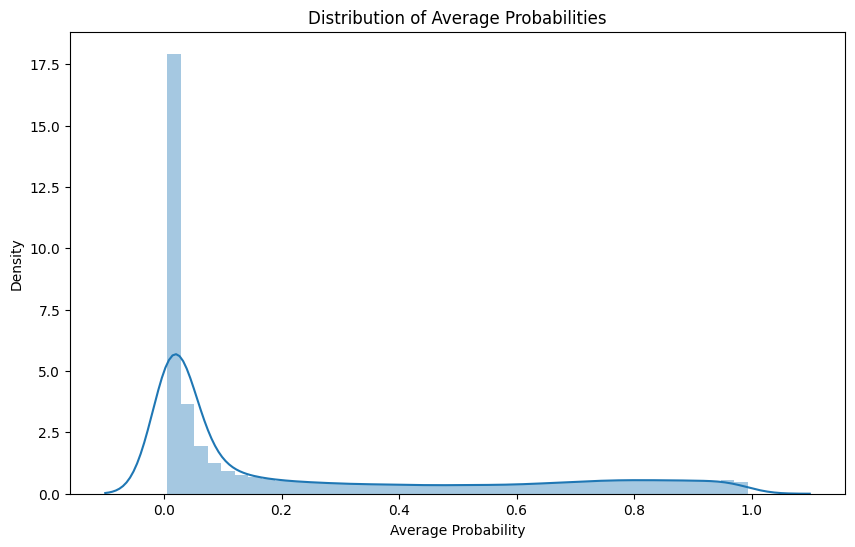

,Statistic,Value
0,Mean,0.246199
1,Median,0.053075
2,Max,0.993860
3,Min,0.005292
4,Count Above Mean,19526.000000
5,Count Below Mean,39123.000000
6,Count Above 95%,1373.000000
7,Count Below 0.7%,1479.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


average_probs_series = unlabeled_df['pred_confidence']


plt.figure(figsize=(10, 6))
sns.distplot(average_probs_series)
plt.title('Distribution of Average Probabilities')
plt.xlabel('Average Probability')
plt.ylabel('Density')
plt.show()

mean_prob = average_probs_series.mean()
median_prob = average_probs_series.median()
max_prob = average_probs_series.max()
min_prob = average_probs_series.min()
above_mean_count = (average_probs_series > mean_prob).sum()
below_mean_count = (average_probs_series < mean_prob).sum()
above_95_count = (average_probs_series > 0.95).sum()
below_7_count = (average_probs_series < 0.007).sum()

stats_table = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Max', 'Min', 'Count Above Mean', 'Count Below Mean', 'Count Above 95%', 'Count Below 0.7%'],
    'Value': [mean_prob, median_prob, max_prob, min_prob, above_mean_count, below_mean_count, above_95_count,below_7_count]
})

stats_table


In [ ]:
low_threshold = 0.007
high_threshold = 0.95

# Filter high-confidence for class 0
selected_class0 = unlabeled_df[unlabeled_df['pred_confidence'] <= low_threshold].copy()
selected_class0['pred_label'] = 0

# Filter high-confidence for class 1
selected_class1 = unlabeled_df[unlabeled_df['pred_confidence'] >= high_threshold].copy()
selected_class1['pred_label'] = 1

# Combine both sets
selected_unlabeled = pd.concat([selected_class0, selected_class1], ignore_index=True)
print(f"High-confidence class 0 samples: {len(selected_class0)}")
print(f"High-confidence class 1 samples: {len(selected_class1)}")
print(f"Total newly labeled samples: {len(selected_unlabeled)}")

High-confidence class 0 samples: 1479
High-confidence class 1 samples: 1373
Total newly labeled samples: 2852


In [ ]:
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

train_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

selected_unlabeled['label'] = selected_unlabeled['pred_label'].astype(int)

augmented_train_df = pd.concat([train_df, selected_unlabeled], ignore_index=True)
print(f"Size of labeled validation data: {len(train_df)}")
print(f"Augmented training set size: {len(augmented_train_df)}")

augmented_train_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/augmented07_95.csv", index=False)

gc.collect()
torch.cuda.empty_cache()

print("Done. Next step: Re-train your DeBERTa model on 'augmented07_95' + evaluate on test set.")

Size of labeled validation data: 1000
Augmented training set size: 3852
Done. Next step: Re-train your DeBERTa model on 'augmented07_95' + evaluate on test set.


In [ ]:
print(selected_unlabeled.shape)
selected_unlabeled.pred_label.value_counts(), augmented_train_df.label.value_counts()

(2852, 14)


(pred_label
 0    1479
 1    1373
 Name: count, dtype: int64,
 label
 0    2055
 1    1797
 Name: count, dtype: int64)

Augmented train samples: 3852
Test samples: 2995


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.2572


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 42: 100%|██████████| 240/240 [01:24<00:00,  2.83it/s]


Epoch 2 completed. Avg Loss: 0.0852


...

Epoch 4 completed. Avg Loss: 0.0298


Finetuning microsoft/deberta-v3-large - Epoch 5, Seed 42: 100%|██████████| 240/240 [01:24<00:00,  2.82it/s]


Epoch 5 completed. Avg Loss: 0.0173


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 42 - Test Accuracy: 0.7713, Spearman: 0.6419
Classification Report:
               precision    recall  f1-score   support

           0     0.7915    0.8506    0.8200      1834
           1     0.7324    0.6460    0.6865      1161

    accuracy                         0.7713      2995
   macro avg     0.7619    0.7483    0.7532      2995
weighted avg     0.7686    0.7713    0.7682      2995

Confusion Matrix:
 [[1560  274]
 [ 411  750]]


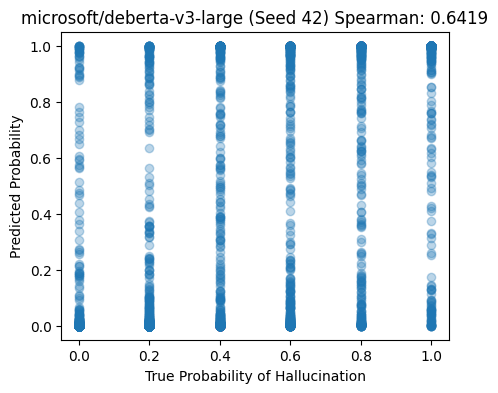

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.2671


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 52: 100%|██████████| 240/240 [01:25<00:00,  2.82it/s]


Epoch 2 completed. Avg Loss: 0.0991


Finetuning microsoft/deberta-v3-large - Epoch 3, Seed 52: 100%|██████████| 240/240 [01:25<00:00,  2.82it/s]


...

Epoch 4 completed. Avg Loss: 0.0142


Finetuning microsoft/deberta-v3-large - Epoch 5, Seed 52: 100%|██████████| 240/240 [01:25<00:00,  2.82it/s]


Epoch 5 completed. Avg Loss: 0.0059


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 52 - Test Accuracy: 0.7509, Spearman: 0.6174
Classification Report:
               precision    recall  f1-score   support

           0     0.8174    0.7639    0.7897      1834
           1     0.6620    0.7304    0.6945      1161

    accuracy                         0.7509      2995
   macro avg     0.7397    0.7472    0.7421      2995
weighted avg     0.7571    0.7509    0.7528      2995

Confusion Matrix:
 [[1401  433]
 [ 313  848]]


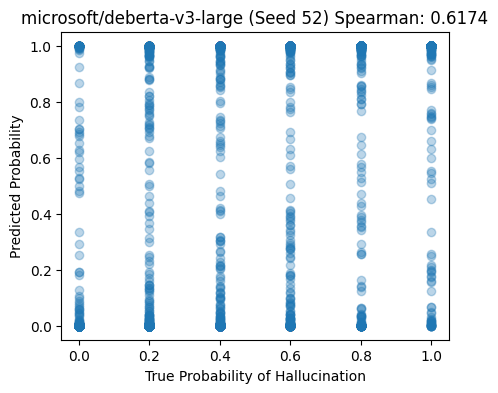

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 completed. Avg Loss: 0.2504


Finetuning microsoft/deberta-v3-large - Epoch 2, Seed 62: 100%|██████████| 240/240 [01:24<00:00,  2.82it/s]


Epoch 2 completed. Avg Loss: 0.0678


Finetuning microsoft/deberta-v3-large - Epoch 3, Seed 62: 100%|██████████| 240/240 [01:25<00:00,  2.82it/s]


...

Epoch 4 completed. Avg Loss: 0.0281


Finetuning microsoft/deberta-v3-large - Epoch 5, Seed 62: 100%|██████████| 240/240 [01:25<00:00,  2.82it/s]


Epoch 5 completed. Avg Loss: 0.0140


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Seed 62 - Test Accuracy: 0.7496, Spearman: 0.6364
Classification Report:
               precision    recall  f1-score   support

           0     0.8371    0.7339    0.7821      1834
           1     0.6482    0.7743    0.7057      1161

    accuracy                         0.7496      2995
   macro avg     0.7426    0.7541    0.7439      2995
weighted avg     0.7638    0.7496    0.7525      2995

Confusion Matrix:
 [[1346  488]
 [ 262  899]]


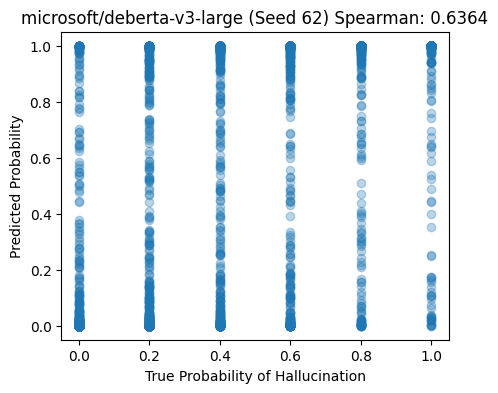


Final Aggregated Results over 3 seeds:
Accuracy: 0.7573 ± 0.0099
Spearman Corr: 0.6319 ± 0.0105


In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm


augmented_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/augmented07_95.csv")  # Combined val + newly labeled high-confidence
print(f"Augmented train samples: {len(augmented_df)}")


test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]
X_test = test_df['combined_input'].tolist()
y_test = test_df['label'].tolist()
p_test = test_df['p(Hallucination)'].tolist()  # For Spearman correlation

print(f"Test samples: {len(test_df)}")


class FinalTrainDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):

        if 'p(Hallucination)' in df.columns:
            self.probs = df['p(Hallucination)'].fillna(0).tolist()
        else:
            self.probs = [0]*len(df)

        self.texts = df['combined_input'].tolist()
        self.labels = df['label'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }

class FinalTestDataset(Dataset):
    def __init__(self, texts, labels, probs, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.probs = probs
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }


def final_train_and_evaluate_deberta(model_name,
                                     train_df_path="/content/drive/MyDrive/SHROOM-Dataset/augmented07_95.csv",
                                     lr=2e-5,
                                     batch_size=8,
                                     epochs=3,
                                     seeds=[42,52,62]):

    acc_scores, spearman_scores = [], []
    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Load augmented train data
        train_aug_df = pd.read_csv(train_df_path)
        train_dataset = FinalTrainDataset(train_aug_df, tokenizer=tokenizer)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
        optimizer = AdamW(model.parameters(), lr=lr)

        # Train
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch in tqdm(train_loader, desc=f"Finetuning {model_name} - Epoch {epoch+1}, Seed {seed}"):
                optimizer.zero_grad()
                outputs = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                    labels=batch['label'].to(device)
                )
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            print(f"Epoch {epoch+1} completed. Avg Loss: {total_loss/len(train_loader):.4f}")
            gc.collect()
            torch.cuda.empty_cache()

        # Final evaluation on Test Set
        test_tokenizer = AutoTokenizer.from_pretrained(model_name)
        test_dataset = FinalTestDataset(X_test, y_test, p_test, test_tokenizer)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model.eval()
        test_preds, test_probs, test_true_labels, test_true_probs = [], [], [], []
        with torch.no_grad():
            for batch in test_loader:
                out = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                )
                logits = out.logits
                prob_batch = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                pred_batch = (prob_batch > 0.5).astype(int)

                test_probs.extend(prob_batch)
                test_preds.extend(pred_batch)
                test_true_labels.extend(batch['label'].cpu().numpy())
                test_true_probs.extend(batch['prob'].cpu().numpy())

        acc = accuracy_score(test_true_labels, test_preds)
        sp_corr, _ = spearmanr(test_true_probs, test_probs)
        acc_scores.append(acc)
        spearman_scores.append(sp_corr)

        print(f"\nSeed {seed} - Test Accuracy: {acc:.4f}, Spearman: {sp_corr:.4f}")
        cls_report = classification_report(test_true_labels, test_preds, digits=4)
        print("Classification Report:\n", cls_report)
        cm = confusion_matrix(test_true_labels, test_preds)
        print("Confusion Matrix:\n", cm)

        # Spearman scatter plot
        plt.figure(figsize=(5, 4))
        plt.scatter(test_true_probs, test_probs, alpha=0.3)
        plt.title(f"{model_name} (Seed {seed}) Spearman: {sp_corr:.4f}")
        plt.xlabel("True Probability of Hallucination")
        plt.ylabel("Predicted Probability")
        plt.show()

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"\nFinal Aggregated Results over {len(seeds)} seeds:")
    print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    print(f"Spearman Corr: {np.mean(spearman_scores):.4f} ± {np.std(spearman_scores):.4f}")

final_train_and_evaluate_deberta(
    model_name="microsoft/deberta-v3-large",
    train_df_path="/content/drive/MyDrive/SHROOM-Dataset/augmented07_95.csv",
    lr=2e-5,
    batch_size=16,
    epochs=5,
    seeds=[42, 52, 62]
)

##### RoBERTA Large MNLI model, <0.7% and >95%

Augmented train samples: 3852
Test samples: 2995


Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large-mnli and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.out_

Epoch 1 completed. Avg Loss: 0.2654


Finetuning roberta-large-mnli - Epoch 2, Seed 42: 100%|██████████| 481/481 [01:14<00:00,  6.46it/s]


Epoch 2 completed. Avg Loss: 0.1343


...

Epoch 3 completed. Avg Loss: 0.0713


Finetuning roberta-large-mnli - Epoch 4, Seed 42: 100%|██████████| 481/481 [01:14<00:00,  6.46it/s]


Epoch 4 completed. Avg Loss: 0.0439


Finetuning roberta-large-mnli - Epoch 5, Seed 42: 100%|██████████| 481/481 [01:14<00:00,  6.46it/s]


Epoch 5 completed. Avg Loss: 0.0665

Seed 42 - Test Accuracy: 0.6811, Spearman: 0.5376
Classification Report:
               precision    recall  f1-score   support

           0     0.8519    0.5802    0.6902      1834
           1     0.5590    0.8407    0.6715      1161

    accuracy                         0.6811      2995
   macro avg     0.7054    0.7104    0.6809      2995
weighted avg     0.7383    0.6811    0.6830      2995

Confusion Matrix:
 [[1064  770]
 [ 185  976]]


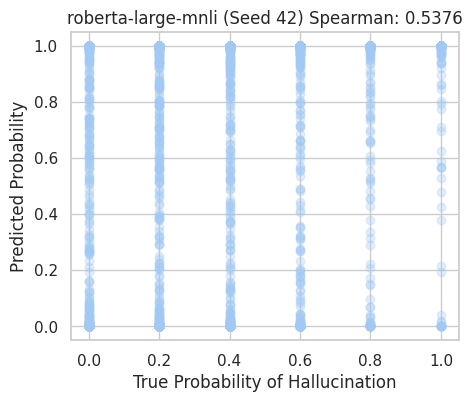

Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large-mnli and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.out_

Epoch 1 completed. Avg Loss: 0.2782


Finetuning roberta-large-mnli - Epoch 2, Seed 52: 100%|██████████| 481/481 [01:14<00:00,  6.45it/s]


Epoch 2 completed. Avg Loss: 0.1412


Finetuning roberta-large-mnli - Epoch 3, Seed 52: 100%|██████████| 481/481 [01:14<00:00,  6.45it/s]


Epoch 3 completed. Avg Loss: 0.0865


Finetuning roberta-large-mnli - Epoch 4, Seed 52: 100%|██████████| 481/481 [01:14<00:00,  6.46it/s]


Epoch 4 completed. Avg Loss: 0.0551


Finetuning roberta-large-mnli - Epoch 5, Seed 52: 100%|██████████| 481/481 [01:14<00:00,  6.45it/s]


Epoch 5 completed. Avg Loss: 0.0745

Seed 52 - Test Accuracy: 0.7065, Spearman: 0.5920
Classification Report:
               precision    recall  f1-score   support

           0     0.8264    0.6592    0.7334      1834
           1     0.5920    0.7812    0.6736      1161

    accuracy                         0.7065      2995
   macro avg     0.7092    0.7202    0.7035      2995
weighted avg     0.7355    0.7065    0.7102      2995

Confusion Matrix:
 [[1209  625]
 [ 254  907]]


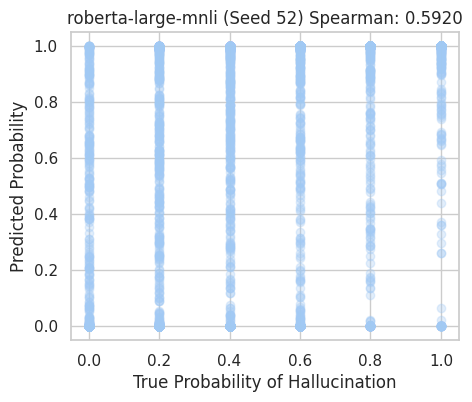

Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large-mnli and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.out_

Epoch 1 completed. Avg Loss: 0.2790


Finetuning roberta-large-mnli - Epoch 2, Seed 62: 100%|██████████| 481/481 [01:14<00:00,  6.44it/s]


Epoch 2 completed. Avg Loss: 0.1571


Finetuning roberta-large-mnli - Epoch 3, Seed 62: 100%|██████████| 481/481 [01:14<00:00,  6.42it/s]


Epoch 3 completed. Avg Loss: 0.0940


Finetuning roberta-large-mnli - Epoch 4, Seed 62: 100%|██████████| 481/481 [01:14<00:00,  6.42it/s]


Epoch 4 completed. Avg Loss: 0.0631


Finetuning roberta-large-mnli - Epoch 5, Seed 62: 100%|██████████| 481/481 [01:14<00:00,  6.44it/s]


Epoch 5 completed. Avg Loss: 0.0526

Seed 62 - Test Accuracy: 0.7235, Spearman: 0.5582
Classification Report:
               precision    recall  f1-score   support

           0     0.7370    0.8528    0.7907      1834
           1     0.6907    0.5194    0.5929      1161

    accuracy                         0.7235      2995
   macro avg     0.7139    0.6861    0.6918      2995
weighted avg     0.7191    0.7235    0.7140      2995

Confusion Matrix:
 [[1564  270]
 [ 558  603]]


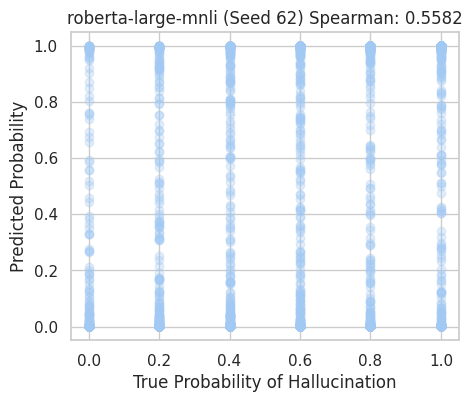


Final Aggregated Results over 3 seeds:
Accuracy: 0.7037 ± 0.0174
Spearman Corr: 0.5626 ± 0.0224


In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm


augmented_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/augmented07_95.csv")  # Combined val + newly labeled high-confidence
print(f"Augmented train samples: {len(augmented_df)}")



labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field in dataset. Ensure probability values exist.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]
X_test = test_df['combined_input'].tolist()
y_test = test_df['label'].tolist()
p_test = test_df['p(Hallucination)'].tolist()  # For Spearman correlation

print(f"Test samples: {len(test_df)}")


class FinalTrainDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):

        if 'p(Hallucination)' in df.columns:
            self.probs = df['p(Hallucination)'].fillna(0).tolist()
        else:
            self.probs = [0]*len(df)

        self.texts = df['combined_input'].tolist()
        self.labels = df['label'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }

class FinalTestDataset(Dataset):
    def __init__(self, texts, labels, probs, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.probs = probs
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'prob': torch.tensor(self.probs[idx], dtype=torch.float)
        }


def final_train_and_evaluate_deberta(model_name,
                                     train_df_path="/content/drive/MyDrive/SHROOM-Dataset/augmented07_95.csv",
                                     lr=2e-5,
                                     batch_size=8,
                                     epochs=3,
                                     seeds=[42,52,62]):

    acc_scores, spearman_scores = [], []
    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Load augmented train data
        train_aug_df = pd.read_csv(train_df_path)
        train_dataset = FinalTrainDataset(train_aug_df, tokenizer=tokenizer)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, ignore_mismatched_sizes=True).to(device)
        optimizer = AdamW(model.parameters(), lr=lr)

        # Train
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch in tqdm(train_loader, desc=f"Finetuning {model_name} - Epoch {epoch+1}, Seed {seed}"):
                optimizer.zero_grad()
                outputs = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                    labels=batch['label'].to(device)
                )
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            print(f"Epoch {epoch+1} completed. Avg Loss: {total_loss/len(train_loader):.4f}")
            gc.collect()
            torch.cuda.empty_cache()

        # Final evaluation on Test Set
        test_tokenizer = AutoTokenizer.from_pretrained(model_name)
        test_dataset = FinalTestDataset(X_test, y_test, p_test, test_tokenizer)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model.eval()
        test_preds, test_probs, test_true_labels, test_true_probs = [], [], [], []
        with torch.no_grad():
            for batch in test_loader:
                out = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                )
                logits = out.logits
                prob_batch = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                pred_batch = (prob_batch > 0.5).astype(int)

                test_probs.extend(prob_batch)
                test_preds.extend(pred_batch)
                test_true_labels.extend(batch['label'].cpu().numpy())
                test_true_probs.extend(batch['prob'].cpu().numpy())

        acc = accuracy_score(test_true_labels, test_preds)
        sp_corr, _ = spearmanr(test_true_probs, test_probs)
        acc_scores.append(acc)
        spearman_scores.append(sp_corr)

        print(f"\nSeed {seed} - Test Accuracy: {acc:.4f}, Spearman: {sp_corr:.4f}")
        cls_report = classification_report(test_true_labels, test_preds, digits=4)
        print("Classification Report:\n", cls_report)
        cm = confusion_matrix(test_true_labels, test_preds)
        print("Confusion Matrix:\n", cm)

        # Spearman scatter plot
        plt.figure(figsize=(5, 4))
        plt.scatter(test_true_probs, test_probs, alpha=0.3)
        plt.title(f"{model_name} (Seed {seed}) Spearman: {sp_corr:.4f}")
        plt.xlabel("True Probability of Hallucination")
        plt.ylabel("Predicted Probability")
        plt.show()

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"\nFinal Aggregated Results over {len(seeds)} seeds:")
    print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    print(f"Spearman Corr: {np.mean(spearman_scores):.4f} ± {np.std(spearman_scores):.4f}")


final_train_and_evaluate_deberta(
    model_name='roberta-large-mnli',
    train_df_path="/content/drive/MyDrive/SHROOM-Dataset/augmented07_95.csv",
    lr=2e-5,
    batch_size=8,
    epochs=5,
    seeds=[42, 52, 62]
)

### Pseudo- Labelling

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("watts2/glove6b50dtxt")

print("Path to dataset files:", path)

100%|██████████| 67.7M/67.7M [00:01<00:00, 57.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/watts2/glove6b50dtxt/versions/1


In [ ]:
import pandas as pd
cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
cleaned_df.shape

(62644, 11)

##### Iterative Method- Finetuned,<=0.007 and >=0.95, Acc -0.7569, Spearman- 0.5850

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)



unlabeled_df = cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ].copy()


unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

# Use only Validation Split
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

val_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }


def train_model(model_name, train_texts, train_labels, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = LabeledDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=8):
    ds = UnlabeledDataset(unlabeled_texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            probs.extend(batch_probs)
    return np.array(probs)


def iterative_self_training(
    model_name,
    train_df,
    unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.95,
    low_threshold=0.007,
    max_iterations=5
):
    labeled_texts = train_df['combined_input'].tolist()
    labeled_labels = train_df['label'].astype(int).tolist()

    for iteration in range(1, max_iterations+1):
        print(f"\n=== Iteration {iteration} ===")
        model, tokenizer = train_model(
            model_name,
            labeled_texts, labeled_labels,
            lr=lr, batch_size=batch_size, epochs=epochs,
            seed=42+iteration  # for slight variation each iteration
        )

        unlabeled_texts = unlabeled_df['combined_input'].tolist()
        pred_probs = predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=batch_size)


        high_conf_1_idx = np.where(pred_probs >= high_threshold)[0]
        high_conf_0_idx = np.where(pred_probs <= low_threshold)[0]
        if len(high_conf_1_idx) == 0 and len(high_conf_0_idx) == 0:
            print("No new high-confidence samples found. Stopping.")
            break


        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1]*len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0]*len(new_texts_0)

        new_texts = new_texts_1 + new_texts_0
        new_labels = new_labels_1 + new_labels_0
        print(f"Newly added samples => 1-class: {len(new_texts_1)}, 0-class: {len(new_texts_0)}")


        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy()
        unlabeled_df.reset_index(drop=True, inplace=True)
        print(f"Remaining unlabeled after iteration: {len(unlabeled_df)}")


        labeled_texts.extend(new_texts)
        labeled_labels.extend(new_labels)
        print(f"Total labeled after iteration: {len(labeled_texts)}")
        print(f"Class balance: {pd.DataFrame(labeled_labels)[0].value_counts().to_dict()}")
        if len(new_texts) < 10:
            print("Fewer than 10 new samples. Stopping self-training.")
            break

    return model, labeled_texts, labeled_labels


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr


train_df = val_df  # rename for clarity

print(f"Starting Self training with {best_model_name} and training set size {len(train_df)}")

# Self-Training
best_model_name = "microsoft/deberta-v3-large"
final_model, final_texts, final_labels = iterative_self_training(
    model_name=best_model_name,
    train_df=train_df,
    unlabeled_df=unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.95,
    low_threshold=0.007,
    max_iterations=5
)

final_model, final_tokenizer = train_model(
    model_name=best_model_name,
    train_texts=final_texts,
    train_labels=final_labels,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    seed=999
)

acc, spcorr = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Starting Self training with microsoft/deberta-v3-large and training set size 1000

=== Iteration 1 ===


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed

Epoch 1 - Avg Loss: 0.6697


Train Epoch 2 Seed 43 with Labelled set size 1000: 100%|██████████| 62/62 [00:21<00:00,  2.82it/s]


Epoch 2 - Avg Loss: 0.5798


...

Epoch 3 - Avg Loss: 0.0349


Train Epoch 4 Seed 999 with Labelled set size 57674: 100%|██████████| 3604/3604 [21:18<00:00,  2.82it/s]


Epoch 4 - Avg Loss: 0.0284


Train Epoch 5 Seed 999 with Labelled set size 57674: 100%|██████████| 3604/3604 [21:19<00:00,  2.82it/s]


Epoch 5 - Avg Loss: 0.0220
Test Accuracy: 0.7569
Classification Report:
              precision    recall  f1-score   support

           0     0.7801    0.8397    0.8088      1834
           1     0.7120    0.6262    0.6664      1161

    accuracy                         0.7569      2995
   macro avg     0.7461    0.7329    0.7376      2995
weighted avg     0.7537    0.7569    0.7536      2995

Confusion Matrix:
[[1540  294]
 [ 434  727]]
Spearman Correlation: 0.5850


In [ ]:
save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2"
final_model.save_pretrained(save_path)
final_tokenizer.save_pretrained(save_path)

('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/tokenizer_config.json',
 '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/special_tokens_map.json',
 '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/spm.model',
 '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/added_tokens.json',
 '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/tokenizer.json')

In [ ]:
final_df = pd.DataFrame({'text':final_texts, 'label':final_labels})
print(final_df.shape)
print(final_df.label.value_counts())
final_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/final_labeled_data.csv", index=False)
final_df.head()

(57674, 2)
label
0    40361
1    17313
Name: count, dtype: int64


,text,label
0,A sloping top . The sides of the casket were c...,1
1,To react too much . Please try not to overreac...,0
2,The process of spoiling ; the state of being s...,1
3,To arrange in a particular way . The way the o...,1
4,A feeling of concern ; a feeling of anxiety . ...,1


###### Evaluation on Benchmark Split (3000)

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid", palette="pastel")

# File paths
file_paths = {

    "Test (Model-Aware)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_test-labeled/test.model-aware.json",
    "Test (Model-Agnostic)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_test-labeled/test.model-agnostic.json",
}

# Function to load JSON data
def load_json_data(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    return data

# Load datasets
datasets = {name: load_json_data(path) for name, path in file_paths.items()}

# Convert datasets to DataFrames
def convert_to_df(name, data):
    df = pd.DataFrame(data)
    df['Dataset'] = name
    return df

dataframes = {name: convert_to_df(name, data) for name, data in datasets.items()}

# Combine all datasets into a single DataFrame for easier analysis
combined_df = pd.concat(dataframes.values(), ignore_index=True)

# Display dataset information
print("Dataset Overview:")
print(combined_df.info())
print("\nSample Data:")
print(combined_df.head())

l_df = combined_df[combined_df['label'].notna()].copy()
l_df['label'] = l_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in l_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

l_df['combined_input'] = (
    l_df['hyp'].fillna('') + ' ' +
    l_df['src'].fillna('') + ' ' +
    l_df['tgt'].fillna('') + ' ' +
    ' ' +
    l_df.get('model','') + ' ' +
    l_df['task'].fillna('')
)
print(l_df.shape)

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                3000 non-null   int64  
 1   src               3000 non-null   object 
 2   tgt               3000 non-null   object 
 3   hyp               3000 non-null   object 
 4   task              3000 non-null   object 
 5   labels            3000 non-null   object 
 6   label             3000 non-null   object 
 7   p(Hallucination)  3000 non-null   float64
 8   Dataset           3000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 211.1+ KB
None

Sample Data:
   id                                                src  \
0   0  Sadly , at the end of his life , Luther became...   
1   4  इतिहासकार लोगन FBI के पिछला नीति के बहुत आलोचन...   
2   5  Àwọn erekùsù ìlà oòrùn adúláwọ̀ wà ní òkun Ind...   
3   9  Smith was first introduced in

In [ ]:
acc, spcorr = evaluate_on_test(final_model, final_tokenizer, l_df, batch_size=8)

Test Accuracy: 0.7573
Classification Report:
              precision    recall  f1-score   support

           0     0.7806    0.8400    0.8092      1838
           1     0.7123    0.6265    0.6667      1162

    accuracy                         0.7573      3000
   macro avg     0.7465    0.7333    0.7379      3000
weighted avg     0.7541    0.7573    0.7540      3000

Confusion Matrix:
[[1544  294]
 [ 434  728]]
Spearman Correlation: 0.5858


###### Class Balance after Pseudo Labelling

Count of Validation Data instances: 1000
Class Balance: label
0    576
1    424
Name: count, dtype: int64
Count of Pseudo Labeled Data instances: 58649
Class Balance: label_int
0    40555
1    18094
Name: count, dtype: int64


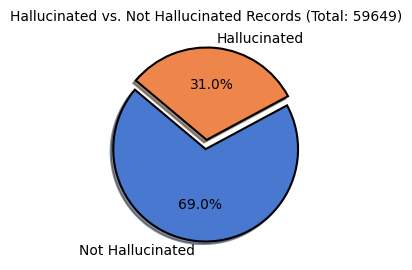

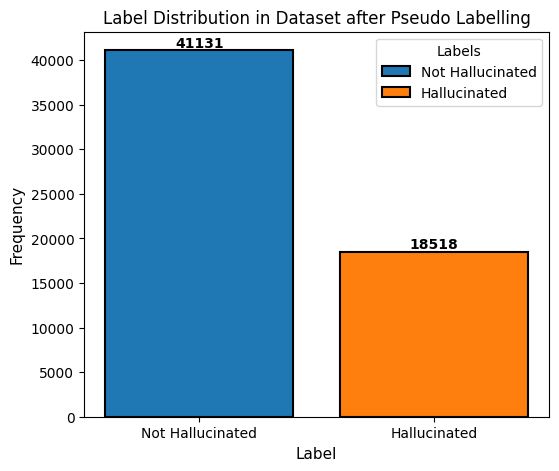

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

val_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
print(f"Count of Validation Data instances: {len(val_df)}")
print(f"Class Balance: {val_df.label.value_counts()}")

pseudo_labeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/labeled_data_complete.csv")
print(f"Count of Pseudo Labeled Data instances: {len(pseudo_labeled_df)}")
print(f"Class Balance: {pseudo_labeled_df.label_int.value_counts()}")

# Aggregate task distribution for Model-Aware & Model-Agnostic tracks
classes = ['Not Hallucinated', 'Hallucinated']
counts = [(x[0]+x[1]) for x in zip(pseudo_labeled_df.label_int.value_counts(), val_df.label.value_counts())]
classes = pd.Series(counts, index=classes)


# Define distinct colors for consistency
colors = sns.color_palette("muted")

# Function to plot a 2D pie chart with a 3D-like effect
def plot_pie_chart(classes, title):
    fig, ax = plt.subplots(figsize=(3, 3))

    # Add depth illusion with shadow and explode
    explode = [0.05] * len(classes)  # Slight separation for a 3D effect

    wedges, texts, autotexts = ax.pie(
        classes, labels=classes.index, autopct='%1.1f%%',
        colors=colors, startangle=140, wedgeprops={"edgecolor": "black", "linewidth": 1.5},
        explode=explode, shadow=True
    )

    # Style the text
    for text in texts + autotexts:
        text.set_fontsize(10)


    ax.set_title(f"{title} (Total: {classes.sum()})", fontsize=10)
    plt.show()

plot_pie_chart(classes, "Hallucinated vs. Not Hallucinated Records")


import pandas as pd
import matplotlib.pyplot as plt

# Data
# Improved Bar Chart with Proper Legends

import pandas as pd
import matplotlib.pyplot as plt

# Data
label_distribution_df = pd.DataFrame({'Labels': ['Not Hallucinated', 'Hallucinated'], 'Counts': [(x[0]+x[1]) for x in zip(pseudo_labeled_df.label_int.value_counts(), val_df.label.value_counts())]})

# Convert 'Counts' column to integer type
label_distribution_df['Counts'] = label_distribution_df['Counts'].astype(int)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Bar plot
bars = ax.bar(
    label_distribution_df['Labels'],
    label_distribution_df['Counts'],
    color=["#1f77b4", "#ff7f0e"],
    edgecolor="black",
    linewidth=1.5
)

# Add count labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight="bold")

# Titles and labels
plt.title("Label Distribution in Dataset after Pseudo Labelling", fontsize=12)
plt.xlabel("Label", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.xticks(rotation=0)
ax.grid(False)
# Add legend manually
plt.legend(bars, ['Not Hallucinated', 'Hallucinated'], title="Labels", loc="upper right")

# Show the plot
plt.show()




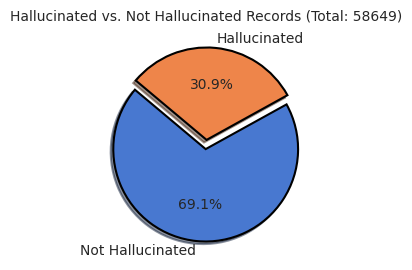

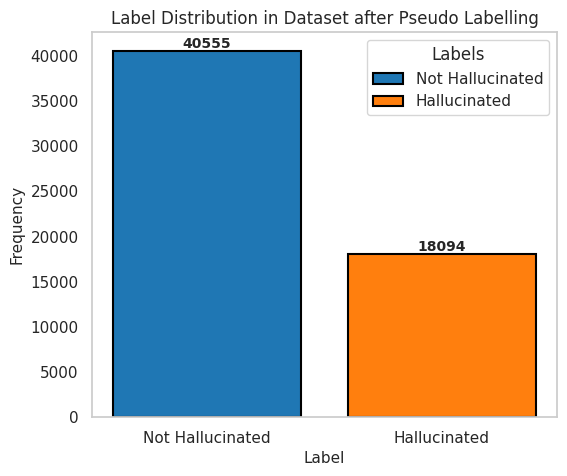

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Aggregate task distribution for Model-Aware & Model-Agnostic tracks
classes = ['Not Hallucinated', 'Hallucinated']
counts = [40555, 18094]
classes = pd.Series(counts, index=classes)


# Define distinct colors for consistency
colors = sns.color_palette("muted")

# Function to plot a 2D pie chart with a 3D-like effect
def plot_pie_chart(classes, title):
    fig, ax = plt.subplots(figsize=(3, 3))

    # Add depth illusion with shadow and explode
    explode = [0.05] * len(classes)  # Slight separation for a 3D effect

    wedges, texts, autotexts = ax.pie(
        classes, labels=classes.index, autopct='%1.1f%%',
        colors=colors, startangle=140, wedgeprops={"edgecolor": "black", "linewidth": 1.5},
        explode=explode, shadow=True
    )

    # Style the text
    for text in texts + autotexts:
        text.set_fontsize(10)


    ax.set_title(f"{title} (Total: {classes.sum()})", fontsize=10)
    plt.show()

plot_pie_chart(classes, "Hallucinated vs. Not Hallucinated Records")


import pandas as pd
import matplotlib.pyplot as plt

# Data
# Improved Bar Chart with Proper Legends

import pandas as pd
import matplotlib.pyplot as plt

# Data
label_distribution_df = pd.DataFrame({'Labels': ['Not Hallucinated', 'Hallucinated'], 'Counts': [40555, 18094]})

# Convert 'Counts' column to integer type
label_distribution_df['Counts'] = label_distribution_df['Counts'].astype(int)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Bar plot
bars = ax.bar(
    label_distribution_df['Labels'],
    label_distribution_df['Counts'],
    color=["#1f77b4", "#ff7f0e"],
    edgecolor="black",
    linewidth=1.5
)

# Add count labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight="bold")

# Titles and labels
plt.title("Label Distribution in Dataset after Pseudo Labelling", fontsize=12)
plt.xlabel("Label", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.xticks(rotation=0)
ax.grid(False)
# Add legend manually
plt.legend(bars, ['Not Hallucinated', 'Hallucinated'], title="Labels", loc="upper right")

# Show the plot
plt.show()



###### Misclassified/ Low Confidence Predictions - 2307

<ipython-input-46-1150ad083931>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(average_probs_series)


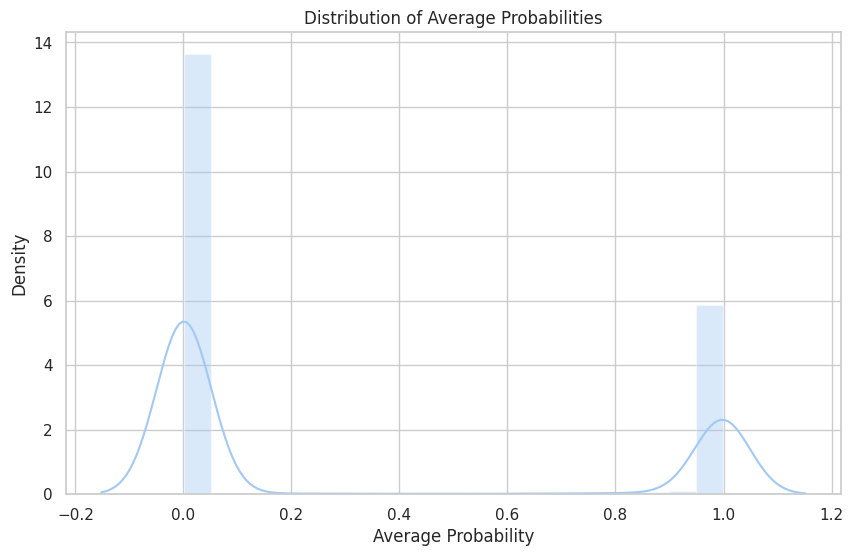

,Statistic,Value
0,Mean,0.307723
1,Max,0.999955
2,Min,0.000127
3,Count Above Mean,18254.000000
4,Count Below Mean,40395.000000
5,Count Above 95%,17214.000000
6,Count Below 0.7%,39128.000000
7,Less Confident Predictions,2307.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


average_probs_series = pred_probs

plt.figure(figsize=(10, 6))
sns.distplot(average_probs_series)
plt.title('Distribution of Average Probabilities')
plt.xlabel('Average Probability')
plt.ylabel('Density')
plt.show()

mean_prob = average_probs_series.mean()
max_prob = average_probs_series.max()
min_prob = average_probs_series.min()
above_mean_count = (average_probs_series > mean_prob).sum()
below_mean_count = (average_probs_series < mean_prob).sum()
above_95_count = (average_probs_series > 0.95).sum()
below_7_count = (average_probs_series < 0.007).sum()
other_count = len(average_probs_series)-above_95_count-below_7_count

stats_table = pd.DataFrame({
    'Statistic': ['Mean', 'Max', 'Min', 'Count Above Mean', 'Count Below Mean', 'Count Above 95%', 'Count Below 0.7%','Less Confident Predictions'],
    'Value': [mean_prob, max_prob, min_prob, above_mean_count, below_mean_count, above_95_count,below_7_count,other_count]
})

stats_table


In [ ]:
final_df.iloc[np.where(np.logical_and(pred_probs < 0.95, pred_probs > 0.007))[0]]

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,pred_confidence,label_int
14,"A substance that , when added to food , makes ...","Something that gives flavor , usually a food i...","This soda has an artificial flavoring , i can ...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN,"A substance that , when added to food , makes ...",0.010990,0
15,Of or pertaining to the Palaiologans .,Pertaining to the reign of the Palaiologans .,"Palaiologan art favoured tall , robust figures...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,NaN,Of or pertaining to the Palaiologans . Palaiol...,0.596675,1
18,A program that translates a program into anoth...,A program that executes another program writte...,Programs written in the basic language are usu...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN,A program that translates a program into anoth...,0.288754,0
45,To spread out in a sprawling manner .,To sit with the limbs spread out .,But most of all i like to sit in the dark with...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN,To spread out in a sprawling manner . But most...,0.227023,0
56,A grove of mesquite trees .,Country or land dominated by mesquite trees .,Southward and in the very center of the plain ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,NaN,A grove of mesquite trees . Southward and in t...,0.779670,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58568,Whiskey,NaN,Whiskey,src,PG,NaN,Train (Model-Agnostic),NaN,Hallucinated,NaN,NaN,Whiskey Whiskey src PG,0.716492,1
58569,That's a no- ⁇ .,NaN,That's not acceptable.,src,PG,NaN,Train (Model-Agnostic),NaN,Hallucinated,NaN,NaN,That's a no- ⁇ . That's not acceptable. src PG,0.907851,1
58575,She left her apartment.,NaN,She's already left.,src,PG,NaN,Train (Model-Agnostic),NaN,Not Hallucinated,NaN,NaN,She left her apartment. She's already left. s...,0.160864,0
58576,Nobody's going to see us.,NaN,No one can see us.,src,PG,NaN,Train (Model-Agnostic),NaN,Not Hallucinated,NaN,NaN,Nobody's going to see us. No one can see us. ...,0.007860,0


In [ ]:
# Model Track distribution for Less confident predictions
print(final_df.iloc[np.where(np.logical_and(final_df['pred_confidence'] < 0.95, final_df['pred_confidence']  > 0.007))[0]].shape)
final_df.iloc[np.where(np.logical_and(final_df['pred_confidence'] < 0.95, final_df['pred_confidence']  > 0.007))[0]].Dataset.value_counts()

(2307, 14)


,count
Dataset,
Train (Model-Aware),1422
Train (Model-Agnostic),885


In [ ]:
## Model Aware / Model Agnostic distribution on labeled_data_complete 58649- for high confidence labels
print(final_df.iloc[np.where(np.logical_or(final_df['pred_confidence'] >= 0.95, final_df['pred_confidence']  <= 0.007))[0]].shape)
final_df.iloc[np.where(np.logical_or(final_df['pred_confidence'] >= 0.95, final_df['pred_confidence']  <= 0.007))[0]].Dataset.value_counts()

(56342, 14)


,count
Dataset,
Train (Model-Aware),28578
Train (Model-Agnostic),27764


###### Analysis Fuzzy Boundary & Low confidence Boundary (0.007 and 0.95)

In [ ]:
import pandas as pd
import numpy as np
fuzzy_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/fuzzy_labdata_activelearning.csv")
fuzzy_df.shape

(2307, 14)

In [ ]:
fuzzy_df = fuzzy_df.iloc[np.where(np.logical_and(fuzzy_df['pred_confidence'] < 0.6, fuzzy_df['pred_confidence'] > 0.4))[0]]
print(fuzzy_df.shape)
fuzzy_df.label.value_counts()

(165, 14)


,count
label,
Hallucinated,92
Not Hallucinated,73


In [ ]:
print(fuzzy_df.Dataset.value_counts())

cleaned_df.Dataset.value_counts()

Dataset
Train (Model-Aware)       116
Train (Model-Agnostic)     49
Name: count, dtype: int64


,count
Dataset,
Train (Model-Aware),30000
Train (Model-Agnostic),28649
Test (Model-Aware),1500
Test (Model-Agnostic),1495
Val (Model-Aware),501
Val (Model-Agnostic),499


In [ ]:
print("\nMissing Values:")
print(fuzzy_df.isnull().sum())


Missing Values:
hyp                   0
tgt                  12
src                   0
ref                   0
task                  0
model                49
Dataset               0
labels              165
label                 0
p(Hallucination)    165
id                  165
combined_input        0
pred_confidence       0
label_int             0
dtype: int64


###### Analysis of class distribution with Fuzzy (1040)

In [ ]:
val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df.label.value_counts()
val_df['label'] = val_df['label'].apply(lambda x: 'Hallucination' if x == 'Hallucination' or x == 'Hallucinated' else 'Not Hallucination')
val_df.label.value_counts()

,count
label,
Not Hallucination,596
Hallucination,444


#### No Fuzzy (1000), DeBERTA scratch, >=0.999 and <=0.0021, Acc - 0.7696, Spearman- 0.6383

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ].copy()


unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

# Use only Validation Split
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

val_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }


def train_model(model_name, train_texts, train_labels, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = LabeledDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=8):
    ds = UnlabeledDataset(unlabeled_texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            probs.extend(batch_probs)
    return np.array(probs)

early_stop = False

def iterative_self_training(
    model_name,
    train_df,
    unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.999,
    low_threshold=0.0021,
    max_iterations=5
):
    labeled_texts = train_df['combined_input'].tolist()
    labeled_labels = train_df['label'].astype(int).tolist()
    pred_conf = train_df['label'].astype(int).tolist()
    best_acc, best_sp = 0.75, 0.6
    global early_stop

    for iteration in range(1, max_iterations+1):
        print(f"\n=== Iteration {iteration} ===")

        model, tokenizer = train_model(
            model_name,
            labeled_texts, labeled_labels,
            lr=lr, batch_size=batch_size, epochs=epochs,
            seed=42+iteration  # for slight variation each iteration
        )

        unlabeled_texts = unlabeled_df['combined_input'].tolist()
        pred_probs = predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=batch_size)

        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pred_probs
        iter_df['pred_labels'] = (pred_probs > 0.5).astype(int)
        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/self_train_newthresh/labeled_data_iteration_{iteration}.csv", index=False)
        print("Unlabeled overall Class balance after prediction: ",iter_df.pred_labels.value_counts())
        # Indices above/below thresholds
        high_conf_1_idx = np.where(pred_probs >= high_threshold)[0]
        high_conf_0_idx = np.where(pred_probs <= low_threshold)[0]
        if len(high_conf_1_idx) == 0 and len(high_conf_0_idx) == 0:
            print("No new high-confidence samples found. Stopping.")
            if not early_stop:
              early_stop = True
            break

        # Create new labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1]*len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0]*len(new_texts_0)

        # Merge them
        new_texts = new_texts_1 + new_texts_0
        new_labels = new_labels_1 + new_labels_0
        pred_conf.extend(np.concatenate([np.array(pred_probs)[high_conf_1_idx.tolist()], np.array(pred_probs)[high_conf_0_idx.tolist()]]).tolist())

        print(f"Newly added samples => 1-class: {len(new_texts_1)}, 0-class: {len(new_texts_0)}")

        # Remove these from unlabeled
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy()
        unlabeled_df.reset_index(drop=True, inplace=True)
        print(f"Remaining unlabeled after iteration: {len(unlabeled_df)}")

        # Add newly labeled to main labeled set
        labeled_texts.extend(new_texts)
        labeled_labels.extend(new_labels)
        print(f"Total labeled after iteration: {len(labeled_texts)}")
        print(f"Class balance (Labeled w/ High Confidence): {pd.DataFrame(labeled_labels)[0].value_counts().to_dict()}")

        print(f'************************** EVALUTION ON TEST SET - {iteration} ************************* ')
        acc, spcorr,pred_probs = evaluate_on_test(model, tokenizer, test_df, batch_size=8)
        if spcorr < 0 or acc < 0.7:
            print("Poor Results. Stopping self-training.")
            early_stop = True
            break
        if acc> best_acc or spcorr> best_sp:
            best_acc, best_sp = acc, spcorr
            save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/self_train_newthresh/SavedModels_{iteration}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)

            #Iterate with the same trained model
            # best_model = model
            # best_tokenizer = tokenizer

            with open(save_path+'/pre_probs_test_2995.pkl', 'wb') as f:
              pickle.dump(pred_probs, f)
              print(save_path+'/pre_probs_test_2995.pkl')

        if len(new_texts) < 100:
            print("Fewer than 100 new samples. Stopping self-training.")
            if not early_stop:
              early_stop = True
            break

    return model, labeled_texts, labeled_labels,pred_conf


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

train_df = val_df  # rename for clarity
best_model_name = "microsoft/deberta-v3-large"
print(f"Starting Self training with {best_model_name} and training set size {len(train_df)}")

# 7.2) Self-Training

final_model, final_texts, final_labels, final_preds = iterative_self_training(
    model_name=best_model_name,
    train_df=train_df,
    unlabeled_df=unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.999,
    low_threshold=0.0021,
    max_iterations=5
)

if not early_stop:
  final_model, final_tokenizer = train_model(
      model_name=best_model_name,
      train_texts=final_texts,
      train_labels=final_labels,
      lr=2e-5,
      batch_size=16,
      epochs=5,
      seed=999
  )

# 7.4) Evaluate on Test
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Unlabeled set size: 58649
Validation set size: 1000
Test set size: 2995
Starting Self training with microsoft/deberta-v3-large and training set size 1000

=== Iteration 1 ===


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Train Epoch 1 Seed 43 with Labelled set size 1000: 100%|██████████| 62/62 [00:22<00:00,  2.80it/s]


Epoch 1 - Avg Loss: 0.6670


Train Epoch 2 Seed 43 with Labelled set size 1000: 100%|██████████| 62/62 [00:22<00:00,  2.81it/s]


Epoch 2 - Avg Loss: 0.5315


...

Epoch 4 - Avg Loss: 0.5849


Train Epoch 5 Seed 45 with Labelled set size 31227: 100%|██████████| 1951/1951 [11:35<00:00,  2.80it/s]


Epoch 5 - Avg Loss: 0.5847
************************** EVALUTION ON TEST SET - 3 ************************* 
Test Accuracy: 0.6124
Classification Report:
              precision    recall  f1-score   support

           0     0.6124    1.0000    0.7596      1834
           1     0.0000    0.0000    0.0000      1161

    accuracy                         0.6124      2995
   macro avg     0.3062    0.5000    0.3798      2995
weighted avg     0.3750    0.6124    0.4651      2995

Confusion Matrix:
[[1834    0]
 [1161    0]]
Spearman Correlation: -0.0065
Poor Results. Stopping self-training.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/transform

KeyboardInterrupt: 

In [ ]:
final_tokenizer = AutoTokenizer.from_pretrained(best_model_name)
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)
pred_probs

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Test Accuracy: 0.6124
Classification Report:
              precision    recall  f1-score   support

           0     0.6124    1.0000    0.7596      1834
           1     0.0000    0.0000    0.0000      1161

    accuracy                         0.6124      2995
   macro avg     0.3062    0.5000    0.3798      2995
weighted avg     0.3750    0.6124    0.4651      2995

Confusion Matrix:
[[1834    0]
 [1161    0]]
Spearman Correlation: -0.0065


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[np.float32(0.25845736),
 np.float32(0.2584574),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845742),
 np.float32(0.2584574),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845733),
 np.float32(0.25845742),
 np.float32(0.25845742),
 np.float32(0.2584574),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845733),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.2584574),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.2584574),
 np.float32(0.2584574),
 np.float32(0.2584574),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.2584574),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845727),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.float32(0.25845736),
 np.floa

In [ ]:
save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/self_train_newthresh"
final_model.save_pretrained(save_path)
final_tokenizer.save_pretrained(save_path)
final_df = pd.DataFrame({'text':final_texts, 'label':final_labels, 'pred_confidence':pred_probs})
print(final_df.shape)
print(final_df.label.value_counts())
final_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/self_train_newthresh/final_labeled_data.csv", index=False)
final_df.head()

('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/tokenizer_config.json',
 '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/special_tokens_map.json',
 '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/spm.model',
 '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/added_tokens.json',
 '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/tokenizer.json')

### Active Learning

##### EDA on Low Confidence Scores

In [ ]:
# import pandas as pd
# import numpy as np
# final_df= pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/labeled_data_complete.csv")
fuzzy_df = final_df.iloc[np.where(np.logical_and(final_df['pred_confidence'] < 0.95, final_df['pred_confidence'] > 0.007))[0]]
fuzzy_df.shape

(2307, 14)

In [ ]:
fuzzy_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/fuzzy_labdata_activelearning.csv", index=False)
fuzzy_df.head()

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,pred_confidence,label_int
14,"A substance that , when added to food , makes ...","Something that gives flavor , usually a food i...","This soda has an artificial flavoring , i can ...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN,"A substance that , when added to food , makes ...",0.010990,0
15,Of or pertaining to the Palaiologans .,Pertaining to the reign of the Palaiologans .,"Palaiologan art favoured tall , robust figures...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,NaN,Of or pertaining to the Palaiologans . Palaiol...,0.596675,1
18,A program that translates a program into anoth...,A program that executes another program writte...,Programs written in the basic language are usu...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN,A program that translates a program into anoth...,0.288754,0
45,To spread out in a sprawling manner .,To sit with the limbs spread out .,But most of all i like to sit in the dark with...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN,To spread out in a sprawling manner . But most...,0.227023,0
56,A grove of mesquite trees .,Country or land dominated by mesquite trees .,Southward and in the very center of the plain ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,NaN,A grove of mesquite trees . Southward and in t...,0.779671,1


Class balance of 'label' column:
label
Not Hallucinated    1427
Hallucinated         880
Name: count, dtype: int64


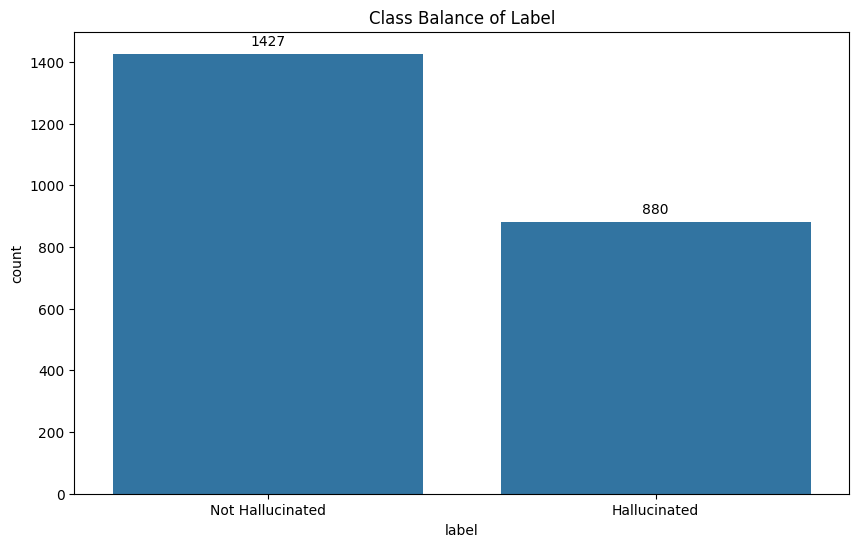


Distribution of 'task' column:
task
DM    1264
MT     825
PG     218
Name: count, dtype: int64


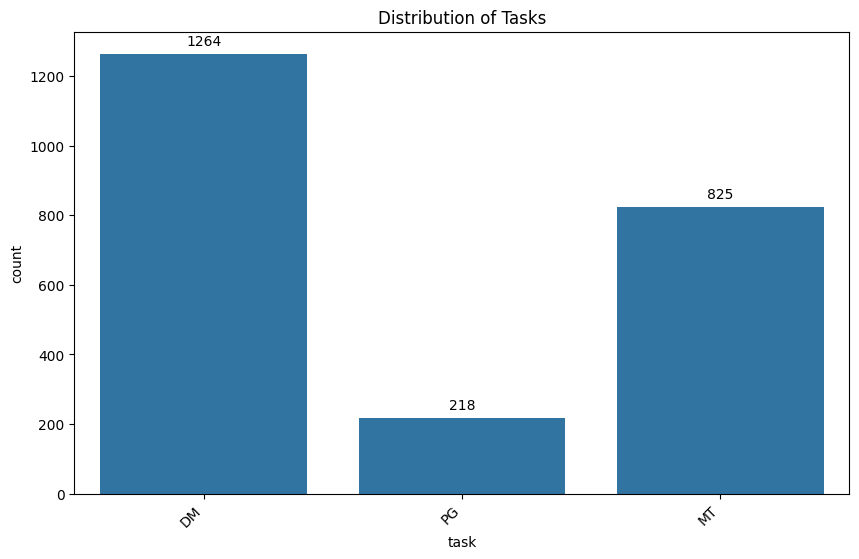

<ipython-input-16-a192379f47f6>:41: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(average_probs_series)


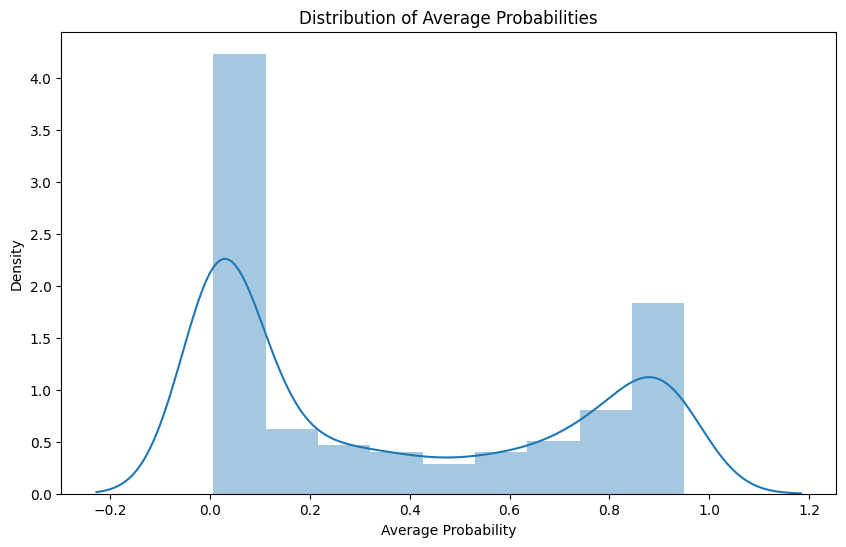


Distribution of 'Dataset' column:
Dataset
Train (Model-Aware)       1422
Train (Model-Agnostic)     885
Name: count, dtype: int64


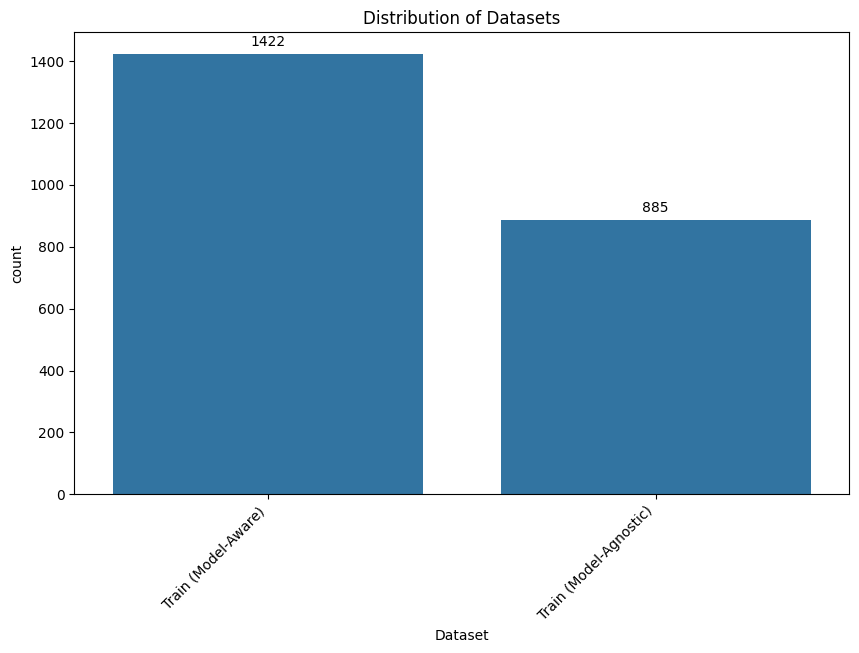

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Class balance of the column label
label_counts = fuzzy_df['label'].value_counts()
print("Class balance of 'label' column:")
print(label_counts)
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=fuzzy_df)
plt.title('Class Balance of Label')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# 2. Distribution for the column task
task_counts = fuzzy_df['task'].value_counts()
print("\nDistribution of 'task' column:")
print(task_counts)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='task', data=fuzzy_df)
plt.title('Distribution of Tasks')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()


# 3. Plot for Distribution of Average Probabilities (column pred_confidence)
plt.figure(figsize=(10, 6))
average_probs_series = fuzzy_df['pred_confidence']
sns.distplot(average_probs_series)
plt.title('Distribution of Average Probabilities')
plt.xlabel('Average Probability')
plt.ylabel('Density')
plt.show()


# 4. Distribution for the column Dataset
dataset_counts = fuzzy_df['Dataset'].value_counts()
print("\nDistribution of 'Dataset' column:")
print(dataset_counts)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Dataset', data=fuzzy_df)
plt.title('Distribution of Datasets')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()



<ipython-input-25-6fcdd8dc35af>:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(average_probs_series)


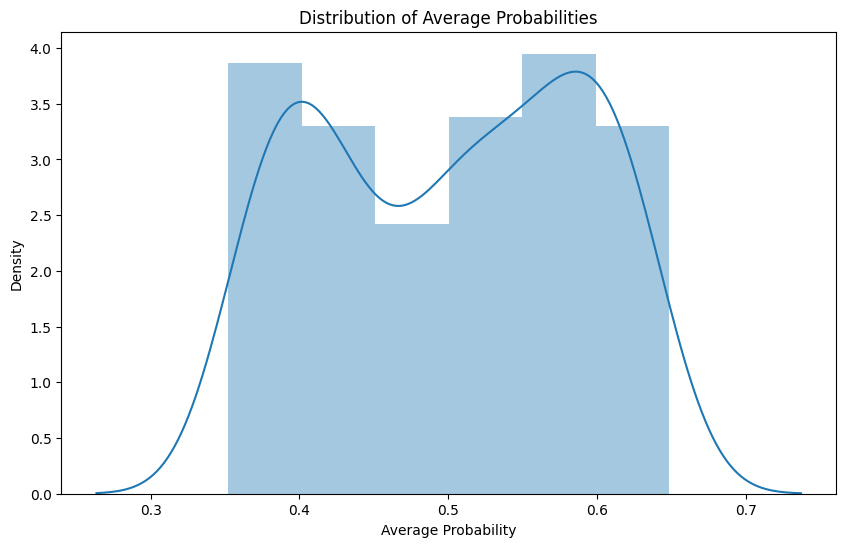

,Statistic,Value
0,Mean,0.501268
1,Max,0.648701
2,Min,0.352113
3,Count Above Mean,132.000000
4,Count Below Mean,119.000000
5,Count Above 35%,119.000000
6,Count Below 65%,132.000000


In [ ]:


import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
average_probs_series = fuzzy_df.iloc[np.where(np.logical_and(fuzzy_df['pred_confidence'] < 0.65, fuzzy_df['pred_confidence'] > 0.35))[0]]['pred_confidence']
sns.distplot(average_probs_series)
plt.title('Distribution of Average Probabilities')
plt.xlabel('Average Probability')
plt.ylabel('Density')


plt.show()
mean_prob = average_probs_series.mean()
max_prob = average_probs_series.max()
min_prob = average_probs_series.min()
above_mean_count = (average_probs_series > mean_prob).sum()
below_mean_count = (average_probs_series < mean_prob).sum()
above_35_count = ((average_probs_series > 0.35) & (average_probs_series < 0.5)).sum()
below_65_count = ((average_probs_series < 0.65) & (average_probs_series > 0.5)).sum()
class_1 =

stats_table = pd.DataFrame({
    'Statistic': ['Mean', 'Max', 'Min', 'Count Above Mean', 'Count Below Mean', 'Count Above 35%', 'Count Below 65%'],
    'Value': [mean_prob, max_prob, min_prob, above_mean_count, below_mean_count, above_35_count,below_65_count]
})

stats_table

In [ ]:
fuzzy_df.iloc[np.where(np.logical_and(fuzzy_df['pred_confidence'] < 0.65, fuzzy_df['pred_confidence'] > 0.35))[0]].label.value_counts()

,count
label,
Hallucinated,132
Not Hallucinated,119


##### Manual Labeling for Active Learning

In [ ]:
# import pandas as pd
# import numpy as np
# fuzzy_cleaned_df= pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/fuzzy_manuallable_cleaned.csv")
print(fuzzy_cleaned_df.shape)
fuzzy_cleaned_df.head()

(40, 15)


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),manual_label,id,combined_input,pred_confidence,label_int
0,Of or pertaining to the Palaiologans .,Pertaining to the reign of the Palaiologans .,"Palaiologan art favoured tall , robust figures...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,Not Hallucinated,NaN,Of or pertaining to the Palaiologans . Palaiol...,0.596675,1
1,In an unconscious manner .,Below the level of conscious awareness .,Sophia broke down here . even at this moment s...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,Not Hallucinated,NaN,In an unconscious manner . Sophia broke down h...,0.541833,1
2,Having the sound of a screech .,Resembling a screech .,A screechy sound . What is the meaning of scre...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,Not Hallucinated,NaN,Having the sound of a screech . A screechy sou...,0.493920,0
3,The quality of being valuable .,The quality ( positive or negative ) that rend...,The shakespearean shylock is of dubious value ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,Not Hallucinated,NaN,The quality of being valuable . The shakespear...,0.589825,1
4,To open up ; to open up ; to open up .,To release from a fold or pen .,To unfold sheep . What is the meaning of unfold ?,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,Hallucinated,NaN,To open up ; to open up ; to open up . To unfo...,0.594418,1


In [ ]:
cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
print(cleaned_df.shape)
print("Train size: ",len(cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ]))
print("Labeled Set size: ",len(cleaned_df[cleaned_df['label'].notna()].copy()))
print("Val size: ",len(cleaned_df[ cleaned_df['Dataset'].str.contains('Val') ]))
print("Test size: ",len(cleaned_df[ cleaned_df['Dataset'].str.contains('Test') ]))

(62644, 11)
Train size:  58649
Labeled Set size:  3995
Val size:  1000
Test size:  2995


In [ ]:
unlabeled_df = cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ].copy()


required_cols = ['hyp', 'tgt', 'src', 'task']
for col in required_cols:
    assert col in fuzzy_cleaned_df.columns, f"Missing column '{col}' in fuzzy_cleaned_df"
    assert col in unlabeled_df.columns, f"Missing column '{col}' in unlabeled_df"


fuzzy_cleaned_df['merge_key'] = fuzzy_cleaned_df['hyp'].fillna('') + '||' + fuzzy_cleaned_df['tgt'].fillna('') + '||' + fuzzy_cleaned_df['src'].fillna('') + '||' + fuzzy_cleaned_df['task'].fillna('')
unlabeled_df['merge_key'] = unlabeled_df['hyp'].fillna('') + '||' + unlabeled_df['tgt'].fillna('') + '||' + unlabeled_df['src'].fillna('') + '||' + unlabeled_df['task'].fillna('')

updated_df = unlabeled_df.merge(
    fuzzy_cleaned_df[['merge_key', 'manual_label']],
    on='merge_key',
    how='left'
)

updated_df['label'] = updated_df['manual_label'].combine_first(updated_df.get('label'))

updated_df.drop(columns=['merge_key', 'manual_label'], inplace=True, errors='ignore')

unlabeled_df = updated_df
print("Train Set Size: ", len(unlabeled_df))
print("New Unlabeled Set Size: ", len(unlabeled_df[unlabeled_df['label'].isna()]))
print("New Labeled Set Size: ", len(unlabeled_df[unlabeled_df['label'].notna()]))

Train Set Size:  58649
New Unlabeled Set Size:  58612
New Labeled Set Size:  37


In [ ]:

fuzzy_cleaned_df['merge_key'] = fuzzy_cleaned_df['hyp'].fillna('') + '||' + fuzzy_cleaned_df['tgt'].fillna('') + '||' + fuzzy_cleaned_df['src'].fillna('') + '||' + fuzzy_cleaned_df['task'].fillna('')
unlabeled_df['merge_key'] = unlabeled_df['hyp'].fillna('') + '||' + unlabeled_df['tgt'].fillna('') + '||' + unlabeled_df['src'].fillna('') + '||' + unlabeled_df['task'].fillna('')

matched_keys = fuzzy_cleaned_df['merge_key'].isin(unlabeled_df['merge_key'])
num_matched = matched_keys.sum()
num_total = len(fuzzy_cleaned_df)

print(f"Matched: {num_matched} / {num_total}")

unmatched_rows = fuzzy_cleaned_df[~matched_keys]
if not unmatched_rows.empty:
    print("\nUnmatched Rows:")
    display(unmatched_rows[['hyp', 'tgt', 'src', 'task', 'manual_label', 'combined_input','merge_key']])

display(unlabeled_df[(unlabeled_df['hyp'].str.contains('In 1956 Slanea moved to Sweden')) | (unlabeled_df['hyp'].str.contains('Pammella Ferguson')) | (unlabeled_df['hyp'].str.contains('Livid.')) ]
)

Matched: 37 / 40

Unmatched Rows:


,hyp,tgt,src,task,manual_label,combined_input,merge_key
22,"In 1956 Slanea moved to Sweden, and three year...","In 1956 S?ania moved to Sweden, where three ye...",1956-ஆம் ஆண்டில் ஸ்லானியா ஸ்வீடனுக்குக் குடிபெ...,MT,Hallucinated,"In 1956 Slanea moved to Sweden, and three year...","In 1956 Slanea moved to Sweden, and three year..."
24,"Pammella Ferguson, a professor at the Universi...",Professor Pamela Ferguson of the University of...,"""ડંડી યુનિવર્સિટીના પ્રાધ્યાપક પામેલા ફર્ગ્યુસ...",MT,Not Hallucinated,"""Pammella Ferguson, a professor at the Univers...","Pammella Ferguson, a professor at the Universi..."
32,(obsolete) Livid.,"Pale, pallid.",15939 Cap somew[hat ] umbon[ate ] smooth <defi...,DM,Hallucinated,(obsolete) Livid. 15939 Cap somew[hat ] umbon[...,"(obsolete) Livid.||Pale, pallid.||15939 Cap so..."


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,merge_key
28770,"In 1956 Slanea moved to Sweden, and three year...","In 1956 Słania moved to Sweden, where three ye...",1956-ஆம் ஆண்டில் ஸ்லானியா ஸ்வீடனுக்குக் குடிபெ...,either,MT,facebook/nllb-200-distilled-600M,Train (Model-Aware),NaN,NaN,NaN,NaN,"In 1956 Slanea moved to Sweden, and three year..."
29219,"""Pammella Ferguson, a professor at the Univers...",Professor Pamela Ferguson of the University of...,"""ડંડી યુનિવર્સિટીના પ્રાધ્યાપક પામેલા ફર્ગ્યુસ...",either,MT,facebook/nllb-200-distilled-600M,Train (Model-Aware),NaN,NaN,NaN,NaN,"""Pammella Ferguson, a professor at the Univers..."
45677,(obsolete) Livid.,"Pale, pallid.",15939 Cap somew[hat ] umbon[ate ] smooth <defi...,tgt,DM,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,"(obsolete) Livid.||Pale, pallid.||15939 Cap so..."


In [ ]:
# Manually label the specified indices in unlabeled_df
unlabeled_df.loc[28770, 'label'] = "Hallucinated"
unlabeled_df.loc[29219, 'label'] = "Not Hallucinated"
unlabeled_df.loc[45677, 'label'] = "Hallucinated"

print("Train Set Size: ", len(unlabeled_df))
print("New Unlabeled Set Size: ", len(unlabeled_df[unlabeled_df['label'].isna()]))
print("New Labeled Set Size: ", len(unlabeled_df[unlabeled_df['label'].notna()]))
#unlabeled_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58649_withfuzzy40.csv", index=False)

Train Set Size:  58649
New Unlabeled Set Size:  58609
New Labeled Set Size:  40


In [ ]:
import pandas as pd
import numpy as np
unlabeled_df= pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58649_withfuzzy40.csv")
unlabeled_df.drop(columns=['merge_key', 'manual_label'], inplace=True, errors='ignore')
print(unlabeled_df[ unlabeled_df['label'].isna()].shape)
print(unlabeled_df[ unlabeled_df['Dataset'].str.contains('Train') ].shape)
unlabeled_df[ unlabeled_df['label'].notna()].head()

(58609, 11)
(58649, 11)


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
15,Of or pertaining to the Palaiologans .,Pertaining to the reign of the Palaiologans .,"Palaiologan art favoured tall , robust figures...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN
110,In an unconscious manner .,Below the level of conscious awareness .,Sophia broke down here . even at this moment s...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN
149,Having the sound of a screech .,Resembling a screech .,A screechy sound . What is the meaning of scre...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN
587,The quality of being valuable .,The quality ( positive or negative ) that rend...,The shakespearean shylock is of dubious value ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucinated,NaN,NaN
1714,To open up ; to open up ; to open up .,To release from a fold or pen .,To unfold sheep . What is the meaning of unfold ?,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucinated,NaN,NaN


##### Adding Fuzzy Samples 40

In [ ]:
train_set = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58649_withfuzzy40.csv")

train_set['label'] = train_set['label'].replace({'Hallucinated': 'Hallucination', 'Not Hallucinated': 'Not Hallucination'})

train_set.label.value_counts()
train_set.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58649_withfuzzy40.csv", index=False)

,count
label,
Not Hallucination,20
Hallucination,20


In [ ]:
#labeled_data = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/labeled_data_complete.csv")
labeled_data.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/labeled_data_complete.csv", index=False)
labeled_data[(labeled_data.task == 'MT') & (labeled_data.label.notna())].tail(20)
# print(labeled_data.label.value_counts())
# labeled_data['label'] = labeled_data['label'].replace({'Hallucinated': 'Hallucination', 'Not Hallucinated': 'Not Hallucination'})
# print(labeled_data.label.value_counts())

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,pred_confidence,label_int
38629,Thank you for telling me.,Thanks for letting me know about this.,"Спасибо, что сообщили мне об этом.",either,MT,NaN,Train (Model-Agnostic),NaN,Not Hallucination,NaN,NaN,"Thank you for telling me. Спасибо, что сообщил...",0.000200,0
38630,We already have one.,We already have one.,У нас уже есть одна.,either,MT,NaN,Train (Model-Agnostic),NaN,Not Hallucination,NaN,NaN,We already have one. У нас уже есть одна. We a...,0.000205,0
38631,No one in their right mind would have done that.,No one in their right mind would do that.,Никто в здравом уме не сделал бы этого.,either,MT,NaN,Train (Model-Agnostic),NaN,Not Hallucination,NaN,NaN,No one in their right mind would have done tha...,0.000162,0
38632,He's not masquerading in his mind.,He doesn't have a head for numbers.,Он не мастак считать в уме.,either,MT,NaN,Train (Model-Agnostic),NaN,Hallucination,NaN,NaN,He's not masquerading in his mind. Он не маста...,0.999683,1
38633,That's extremely interesting.,That's extremely interesting.,Это чрезвычайно интересно.,either,MT,NaN,Train (Model-Agnostic),NaN,Not Hallucination,NaN,NaN,That's extremely interesting. Это чрезвычайно ...,0.000159,0
38634,Soup's not cold yet.,The soup is still hot.,Суп ещё не остыл.,either,MT,NaN,Train (Model-Agnostic),NaN,Hallucination,NaN,NaN,Soup's not cold yet. Суп ещё не остыл. The sou...,0.999161,1
38635,The wind was exasperating.,The wind was howling.,Ветер завывал.,either,MT,NaN,Train (Model-Agnostic),NaN,Hallucination,NaN,NaN,The wind was exasperating. Ветер завывал. The ...,0.999322,1
38636,Why don't we go with Tom?,Why don't we go with Tom?,Почему бы нам не пойти с Томом?,either,MT,NaN,Train (Model-Agnostic),NaN,Not Hallucination,NaN,NaN,Why don't we go with Tom? Почему бы нам не пой...,0.000159,0
38637,I'm glad I'm alive.,I'm glad to be alive.,"Я рад, что жив.",either,MT,NaN,Train (Model-Agnostic),NaN,Not Hallucination,NaN,NaN,"I'm glad I'm alive. Я рад, что жив. I'm glad t...",0.000194,0
38638,Tom says he's innocent.,Tom says he's innocent.,"Том говорит, что невиновен.",either,MT,NaN,Train (Model-Agnostic),NaN,Not Hallucination,NaN,NaN,"Tom says he's innocent. Том говорит, что невин...",0.000196,0


In [ ]:
import pandas as pd
import numpy as np

labeled_data = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/labeled_data_complete.csv")

train_set = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58649_withfuzzy40.csv")
train_set.drop(columns=['merge_key', 'manual_label'], inplace=True, errors='ignore')

fuzzy_df = train_set[train_set['label'].notna()].copy()
fuzzy_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/fuzzy_samples40.csv", index=False)
fuzzy_df['combined_input'] = (
    fuzzy_df['hyp'].fillna('') + ' ' +
    fuzzy_df['src'].fillna('') + ' ' +
    fuzzy_df['tgt'].fillna('') + ' ' +
    fuzzy_df['ref'].fillna('') + ' ' +
    fuzzy_df['model'].fillna('') + ' ' +
    fuzzy_df['task'].fillna('')
)


pseudo_labeled_df = labeled_data.iloc[np.where(np.logical_or(labeled_data['pred_confidence'] >= 0.95, labeled_data['pred_confidence']  <= 0.007))[0]] #56k
unlabeled_df = labeled_data.iloc[np.where(np.logical_and(labeled_data['pred_confidence'] < 0.95, labeled_data['pred_confidence']  > 0.007))[0]] #2307

# Ensure 'combined_input' exists in both DataFrames
if 'combined_input' not in unlabeled_df.columns or 'combined_input' not in fuzzy_df.columns:
    raise KeyError("Both DataFrames must contain the 'combined_input' column.")

# Filter out rows in unlabeled_df that match any combined_input in fuzzy_df
unlabeled_df = unlabeled_df[~unlabeled_df['combined_input'].isin(fuzzy_df['combined_input'])].copy()
unlabeled_df.reset_index(drop=True, inplace=True)

print(f"Remaining records in unlabeled_df after removal: {len(unlabeled_df)}") #2267


## Model Aware / Model Agnostic distribution on labeled_data_complete 58649- for high confidence labels
print(pseudo_labeled_df.shape)
print(fuzzy_df.shape)
print(unlabeled_df.shape)
print(pseudo_labeled_df.label.value_counts())
pseudo_labeled_df.Dataset.value_counts()

Remaining records in unlabeled_df after removal: 2267
(56342, 14)
(40, 12)
(2267, 14)
label
Not Hallucination    39128
Hallucination        17214
Name: count, dtype: int64


,count
Dataset,
Train (Model-Aware),28578
Train (Model-Agnostic),27764


In [ ]:
# new_trainset = pd.concat([pseudo_labeled_df, fuzzy_df])
# print(new_trainset.shape) #56382
new_trainset.head()

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,pred_confidence,label_int
0,Of or pertaining to the language of a particul...,"Of or pertaining to everyday language , as opp...","There are blacktips , silvertips , bronze whal...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucination,NaN,NaN,Of or pertaining to the language of a particul...,0.999045,1.0
1,Not coercive ; not involving coercion,Not coercive ; free of coercion,Mr. obama signed executive orders requiring al...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN,Not coercive ; not involving coercion Mr. obam...,0.000249,0.0
2,To express or express by words ; to express by...,To depict or portray .,Disloyal ? / the word is too good to paint out...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN,To express or express by words ; to express by...,0.000454,0.0
3,Having the power to authoritatively speak or w...,Having a commanding style .,"He instructed us in that booming , authoritati...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucination,NaN,NaN,Having the power to authoritatively speak or w...,0.995571,1.0
4,Without a scot .,"Without consequences or penalties , to go free...",To get off scot-free . What is the meaning of ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucination,NaN,NaN,Without a scot . To get off scot-free . What i...,0.999518,1.0


In [ ]:
print(unlabeled_df.shape)
unlabeled_df.label.value_counts()
#unlabeled_df.to_csv('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabelled_2267.csv', index=False)
unlabeled_df.head()

(2267, 14)


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,pred_confidence,label_int
0,"A substance that , when added to food , makes ...","Something that gives flavor , usually a food i...","This soda has an artificial flavoring , i can ...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN,"A substance that , when added to food , makes ...",0.010990,0
1,A program that translates a program into anoth...,A program that executes another program writte...,Programs written in the basic language are usu...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN,A program that translates a program into anoth...,0.288754,0
2,To spread out in a sprawling manner .,To sit with the limbs spread out .,But most of all i like to sit in the dark with...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN,To spread out in a sprawling manner . But most...,0.227023,0
3,A grove of mesquite trees .,Country or land dominated by mesquite trees .,Southward and in the very center of the plain ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucination,NaN,NaN,A grove of mesquite trees . Southward and in t...,0.779671,1
4,The act of betting .,Describing one who bets or gambles .,"If i were a betting man , i 'd wager my next p...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN,"The act of betting . If i were a betting man ,...",0.037924,0


### Active Learning Experiments

##### With Fuzzy (1040) DeBERTA, >=0.95 and <=0.007. Saved Best Model-1. Acc- 0.7593, Spearman- 0.6058

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
train_set = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58649_withfuzzy40.csv")
train_set.drop(columns=['merge_key', 'manual_label'], inplace=True, errors='ignore')

val_df = pd.concat([cleaned_df[cleaned_df['Dataset'].str.contains('Val')], train_set[train_set['label'].notna() ]])
test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')].copy()

unlabeled_df = train_set[train_set['label'].isna()].copy()

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

print(f"Unlabeled set size: {len(unlabeled_df)}")

def preprocess_dataframe(df):

    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)


    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")
print(f"Test set balance: {(test_df.label.value_counts().to_dict())}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }


def train_model(model_name, train_texts, train_labels, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = LabeledDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=8):
    ds = UnlabeledDataset(unlabeled_texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            probs.extend(batch_probs)
    return np.array(probs)


def iterative_self_training(
    model_name,
    train_df,
    unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.95,
    low_threshold=0.007,
    max_iterations=5
):
    labeled_texts = train_df['combined_input'].tolist()
    labeled_labels = train_df['label'].astype(int).tolist()

    best_acc, best_sp = 0, 0

    for iteration in range(1, max_iterations+1):
        print(f"\n=== Iteration {iteration} ===")
        model, tokenizer = train_model(
            model_name,
            labeled_texts, labeled_labels,
            lr=lr, batch_size=batch_size, epochs=epochs,
            seed=42+iteration  # for slight variation each iteration
        )

        unlabeled_texts = unlabeled_df['combined_input'].tolist()
        pred_probs = predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=batch_size)

        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pred_probs
        iter_df['pred_labels'] = (pred_probs > 0.5).astype(int)
        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/labeled_data_iteration_{iteration}.csv", index=False)
        print("Unlabeled overall Class balance after prediction: ",iter_df.pred_labels.value_counts())
        # Indices above/below thresholds
        high_conf_1_idx = np.where(pred_probs >= high_threshold)[0]
        high_conf_0_idx = np.where(pred_probs <= low_threshold)[0]
        if len(high_conf_1_idx) == 0 and len(high_conf_0_idx) == 0:
            print("No new high-confidence samples found. Stopping.")
            break

        # Create new labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1]*len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0]*len(new_texts_0)

        # Merge them
        new_texts = new_texts_1 + new_texts_0
        new_labels = new_labels_1 + new_labels_0

        print(f"Newly added samples => 1-class: {len(new_texts_1)}, 0-class: {len(new_texts_0)}")

        # Remove these from unlabeled
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy()
        unlabeled_df.reset_index(drop=True, inplace=True)
        print(f"Remaining unlabeled after iteration: {len(unlabeled_df)}")

        # Add newly labeled to main labeled set
        labeled_texts.extend(new_texts)
        labeled_labels.extend(new_labels)
        print(f"Total labeled after iteration: {len(labeled_texts)}")
        print(f"Class balance (Labeled w/ High Confidence): {pd.DataFrame(labeled_labels)[0].value_counts().to_dict()}")


        print(f'************************** EVALUTION ON TEST SET - {iteration} ************************* ')
        acc, spcorr,pred_probs = evaluate_on_test(model, tokenizer, test_df, batch_size=8)
        if acc> best_acc or spcorr> best_sp:
            best_acc, best_sp = acc, spcorr
            save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/SavedModels_{iteration}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)

            with open(save_path+'/pre_probs_test_2995.pkl', 'wb') as f:
              pickle.dump(pred_probs, f)
              print(save_path+'/pre_probs_test_2995.pkl')


        if len(new_texts) < 100:
            print("Fewer than 100 new samples. Stopping self-training.")
            break

    return model, labeled_texts, labeled_labels


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

train_df = val_df  # rename for clarity
best_model_name = "microsoft/deberta-v3-large"
print(f"Starting Self training with {best_model_name} and training set size {len(train_df)}")

# Self-Training
final_model, final_texts, final_labels = iterative_self_training(
    model_name=best_model_name,
    train_df=train_df,
    unlabeled_df=unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.95,
    low_threshold=0.007,
    max_iterations=3
)

final_model, final_tokenizer = train_model(
    model_name=best_model_name,
    train_texts=final_texts,
    train_labels=final_labels,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    seed=999
)

acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995
Test set balance: {0: 1834, 1: 1161}
Starting Self training with microsoft/deberta-v3-large and training set size 1040

=== Iteration 1 ===


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


...

Epoch 3 - Avg Loss: 0.0286


Train Epoch 4 Seed 999 with Labelled set size 39393: 100%|██████████| 2462/2462 [31:19<00:00,  1.31it/s]


Epoch 4 - Avg Loss: 0.1870


Train Epoch 5 Seed 999 with Labelled set size 39393: 100%|██████████| 2462/2462 [31:20<00:00,  1.31it/s]


Epoch 5 - Avg Loss: 0.1273
Test Accuracy: 0.7593
Classification Report:
              precision    recall  f1-score   support

           0     0.8000    0.8092    0.8046      1834
           1     0.6930    0.6804    0.6867      1161

    accuracy                         0.7593      2995
   macro avg     0.7465    0.7448    0.7456      2995
weighted avg     0.7585    0.7593    0.7589      2995

Confusion Matrix:
[[1484  350]
 [ 371  790]]
Spearman Correlation: 0.6058


#### With Fuzzy (1040), DeBERTA scratch, >=0.95 and <=0.007 but with balanced class pseudo labeling, Acc- 0.7643, Spearman- 0.6253

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }


def train_model(model_name, train_texts, train_labels, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = LabeledDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=8):
    ds = UnlabeledDataset(unlabeled_texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            probs.extend(batch_probs)
    return np.array(probs)

early_stop = False

def iterative_self_training(
    model_name,
    train_df,
    unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.95,
    low_threshold=0.007,
    max_iterations=5
):
    labeled_texts = train_df['combined_input'].tolist()
    labeled_labels = train_df['label'].astype(int).tolist()
    best_acc, best_sp = 0.75, 0.6
    global early_stop

    for iteration in range(1, max_iterations+1):
        print(f"\n=== Iteration {iteration} ===")

        model, tokenizer = train_model(
            model_name,
            labeled_texts, labeled_labels,
            lr=lr, batch_size=batch_size, epochs=epochs,
            seed=42+iteration  # for slight variation each iteration
        )

        unlabeled_texts = unlabeled_df['combined_input'].tolist()
        pred_probs = predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=batch_size)

        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pred_probs
        iter_df['pred_labels'] = (pred_probs > 0.5).astype(int)
        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/self_train_newthresh/labeled_databalance1040_iteration_{iteration}.csv", index=False)
        print("Unlabeled overall Class balance after prediction: ",iter_df.pred_labels.value_counts())
        # Indices above/below thresholds
        high_conf_1_idx = np.where(pred_probs >= high_threshold)[0]
        high_conf_0_idx = np.where(pred_probs <= low_threshold)[0]
        if len(high_conf_1_idx) == 0 and len(high_conf_0_idx) == 0:
            print("No new high-confidence samples found. Stopping.")
            if not early_stop:
              early_stop = True
            break
        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))

        # Shuffle to avoid bias before truncating
        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)

        # Truncate both to the same length for class balance
        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]
        # Create new balanced labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1]*len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0]*len(new_texts_0)

        # Merge them
        new_texts = new_texts_1 + new_texts_0
        new_labels = new_labels_1 + new_labels_0

        print(f"Newly added samples => 1-class: {len(new_texts_1)}, 0-class: {len(new_texts_0)}")

        # Remove these from unlabeled
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy()
        unlabeled_df.reset_index(drop=True, inplace=True)
        print(f"Remaining unlabeled after iteration: {len(unlabeled_df)}")

        # Add newly labeled to main labeled set
        labeled_texts.extend(new_texts)
        labeled_labels.extend(new_labels)
        print(f"Total labeled after iteration: {len(labeled_texts)}")
        print(f"Class balance (Labeled w/ High Confidence): {pd.DataFrame(labeled_labels)[0].value_counts().to_dict()}")


        print(f'************************** EVALUTION ON TEST SET - {iteration} ************************* ')
        acc, spcorr,pred_probs = evaluate_on_test(model, tokenizer, test_df, batch_size=8)
        if spcorr < 0 or acc < 0.7:
            print("Poor Results. Stopping self-training.")
            early_stop = True
            break
        if acc> best_acc or spcorr> best_sp:
            best_acc, best_sp = acc, spcorr
            save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/self_train_newthresh/SavedModels1040_databalance{iteration}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)

            with open(save_path+'/pre_probs_test_2995.pkl', 'wb') as f:
              pickle.dump(pred_probs, f)
              print(save_path+'/pre_probs_test_2995.pkl')


        # Early stopping condition if we got too few new samples
        if len(new_texts) < 100:
            print("Fewer than 10 new samples. Stopping self-training.")
            if not early_stop:
              early_stop = True
            break

    return model, labeled_texts, labeled_labels


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()
    # If you have p(Hallucination) in the test, use it for Spearman
    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

train_df = val_df  # rename for clarity
best_model_name = "microsoft/deberta-v3-large"
print(f"Starting Self training with {best_model_name} and training set size {len(train_df)}")

# 7.2) Self-Training

final_model, final_texts, final_labels = iterative_self_training(
    model_name=best_model_name,
    train_df=train_df,
    unlabeled_df=unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.95,
    low_threshold=0.007,
    max_iterations=3
)

if not early_stop:
  final_model, final_tokenizer = train_model(
      model_name=best_model_name,
      train_texts=final_texts,
      train_labels=final_labels,
      lr=2e-5,
      batch_size=16,
      epochs=5,
      seed=999
  )
else:
  final_tokenizer = AutoTokenizer.from_pretrained(best_model_name)

# 7.4) Evaluate on Test
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995
Starting Self training with microsoft/deberta-v3-large and training set size 1040

=== Iteration 1 ===


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Train Epoch 1 Seed 43 with Labelled set size 1040: 100%|██████████| 65/65 [00:23<00:00,  2.78it/s]


Epoch 1 - Avg Loss: 0.6662


Train Epoch 2 Seed 43 with Labelled set size 1040: 100%|██████████| 65/65 [00:23<00:00,  2.79it/s]


Epoch 2 - Avg Loss: 0.5494


...

Train Epoch 4 Seed 999 with Labelled set size 43866: 100%|██████████| 2741/2741 [16:23<00:00,  2.79it/s]


Epoch 4 - Avg Loss: 0.0467


Train Epoch 5 Seed 999 with Labelled set size 43866: 100%|██████████| 2741/2741 [16:23<00:00,  2.79it/s]


Epoch 5 - Avg Loss: 0.6057
Test Accuracy: 0.6124
Classification Report:
              precision    recall  f1-score   support

           0     0.6124    1.0000    0.7596      1834
           1     0.0000    0.0000    0.0000      1161

    accuracy                         0.6124      2995
   macro avg     0.3062    0.5000    0.3798      2995
weighted avg     0.3750    0.6124    0.4651      2995

Confusion Matrix:
[[1834    0]
 [1161    0]]
Spearman Correlation: 0.0265


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Increased Threshold ≥ 0.999 and ≤ 0.0021, Acc- 0.7566,Spearman- 0.6002



In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }


def train_model(model_name, train_texts, train_labels, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = LabeledDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=8):
    ds = UnlabeledDataset(unlabeled_texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            probs.extend(batch_probs)
    return np.array(probs)

early_stop = False

def iterative_self_training(
    model_name,
    train_df,
    unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.999,
    low_threshold=0.0021,
    max_iterations=5
):
    labeled_texts = train_df['combined_input'].tolist()
    labeled_labels = train_df['label'].astype(int).tolist()
    pred_conf = train_df['label'].astype(int).tolist()
    best_acc, best_sp = 0.75, 0.6
    global early_stop

    for iteration in range(1, max_iterations+1):
        print(f"\n=== Iteration {iteration} ===")

        model, tokenizer = train_model(
            model_name,
            labeled_texts, labeled_labels,
            lr=lr, batch_size=batch_size, epochs=epochs,
            seed=42+iteration  # for slight variation each iteration
        )

        unlabeled_texts = unlabeled_df['combined_input'].tolist()
        pred_probs = predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=batch_size)

        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pred_probs
        iter_df['pred_labels'] = (pred_probs > 0.5).astype(int)
        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/self_train_newthresh/labeled_data1040_iteration_{iteration}.csv", index=False)
        print("Unlabeled overall Class balance after prediction: ",iter_df.pred_labels.value_counts())
        # Indices above/below thresholds
        high_conf_1_idx = np.where(pred_probs >= high_threshold)[0]
        high_conf_0_idx = np.where(pred_probs <= low_threshold)[0]
        if len(high_conf_1_idx) == 0 and len(high_conf_0_idx) == 0:
            print("No new high-confidence samples found. Stopping.")
            if not early_stop:
              early_stop = True
            break

        # Create new labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1]*len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0]*len(new_texts_0)

        # Merge them
        new_texts = new_texts_1 + new_texts_0
        new_labels = new_labels_1 + new_labels_0
        pred_conf.extend(np.concatenate([np.array(pred_probs)[high_conf_1_idx.tolist()], np.array(pred_probs)[high_conf_0_idx.tolist()]]).tolist())

        print(f"Newly added samples => 1-class: {len(new_texts_1)}, 0-class: {len(new_texts_0)}")

        # Remove these from unlabeled
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy()
        unlabeled_df.reset_index(drop=True, inplace=True)
        print(f"Remaining unlabeled after iteration: {len(unlabeled_df)}")

        # Add newly labeled to main labeled set
        labeled_texts.extend(new_texts)
        labeled_labels.extend(new_labels)
        print(f"Total labeled after iteration: {len(labeled_texts)}")
        print(f"Class balance (Labeled w/ High Confidence): {pd.DataFrame(labeled_labels)[0].value_counts().to_dict()}")


        print(f'************************** EVALUTION ON TEST SET - {iteration} ************************* ')
        acc, spcorr,pred_probs = evaluate_on_test(model, tokenizer, test_df, batch_size=8)
        if spcorr < 0 or acc < 0.7:
            print("Poor Results. Stopping self-training.")
            early_stop = True
            break
        if acc> best_acc or spcorr> best_sp:
            best_acc, best_sp = acc, spcorr
            save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/self_train_newthresh/SavedModels1040_{iteration}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)

            with open(save_path+'/pre_probs_test_2995.pkl', 'wb') as f:
              pickle.dump(pred_probs, f)
              print(save_path+'/pre_probs_test_2995.pkl')

        if len(new_texts) < 100:
            print("Fewer than 10 new samples. Stopping self-training.")
            if not early_stop:
              early_stop = True
            break

    return model, labeled_texts, labeled_labels,pred_conf


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

train_df = val_df  # rename for clarity
best_model_name = "microsoft/deberta-v3-large"
print(f"Starting Self training with {best_model_name} and training set size {len(train_df)}")

# 7.2) Self-Training

final_model, final_texts, final_labels, final_preds = iterative_self_training(
    model_name=best_model_name,
    train_df=train_df,
    unlabeled_df=unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.999,
    low_threshold=0.0021,
    max_iterations=3
)

if not early_stop:
  final_model, final_tokenizer = train_model(
      model_name=best_model_name,
      train_texts=final_texts,
      train_labels=final_labels,
      lr=2e-5,
      batch_size=16,
      epochs=5,
      seed=999
  )
else:
  final_tokenizer = AutoTokenizer.from_pretrained(best_model_name)

# 7.4) Evaluate on Test
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995
Starting Self training with microsoft/deberta-v3-large and training set size 1040

=== Iteration 1 ===


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Train Epoch 1 Seed 43 with Labelled set size 1040: 100%|██████████| 65/65 [00:23<00:00,  2.77it/s]


Epoch 1 - Avg Loss: 0.6662


Train Epoch 2 Seed 43 with Labelled set size 1040: 100%|██████████| 65/65 [00:23<00:00,  2.79it/s]


Epoch 2 - Avg Loss: 0.5494


...

Train Epoch 5 Seed 45 with Labelled set size 39163: 100%|██████████| 2447/2447 [14:36<00:00,  2.79it/s]


Epoch 5 - Avg Loss: 0.4448
Unlabeled overall Class balance after prediction:  pred_labels
0    20486
Name: count, dtype: int64
No new high-confidence samples found. Stopping.


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Test Accuracy: 0.6124
Classification Report:
              precision    recall  f1-score   support

           0     0.6124    1.0000    0.7596      1834
           1     0.0000    0.0000    0.0000      1161

    accuracy                         0.6124      2995
   macro avg     0.3062    0.5000    0.3798      2995
weighted avg     0.3750    0.6124    0.4651      2995

Confusion Matrix:
[[1834    0]
 [1161    0]]
Spearman Correlation: -0.0494


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### With Fuzzy (1040), DeBERTA scratch, >=0.999 and <= 0.0021 but with balanced class pseudo labeling, Acc-0.7693, Spearman- 0.6158
Since it is balanced on class the first few iterations with only 1 class predictions are nullified -> So no new pseudo labels added

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }


def train_model(model_name, train_texts, train_labels, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = LabeledDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=8):
    ds = UnlabeledDataset(unlabeled_texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            probs.extend(batch_probs)
    return np.array(probs)

early_stop = False

def iterative_self_training(
    model_name,
    train_df,
    unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.999,
    low_threshold=0.0021,
    max_iterations=5
):
    labeled_texts = train_df['combined_input'].tolist()
    labeled_labels = train_df['label'].astype(int).tolist()
    best_acc, best_sp = 0.7, 0.6
    global early_stop

    for iteration in range(1, max_iterations+1):
        print(f"\n=== Iteration {iteration} ===")

        model, tokenizer = train_model(
            model_name,
            labeled_texts, labeled_labels,
            lr=lr, batch_size=batch_size, epochs=epochs,
            seed=42+iteration  # for slight variation each iteration
        )

        unlabeled_texts = unlabeled_df['combined_input'].tolist()
        pred_probs = predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=batch_size)

        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pred_probs
        iter_df['pred_labels'] = (pred_probs > 0.5).astype(int)
        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/labeled_databalance1040_iteration_{iteration}.csv", index=False)
        print("Unlabeled overall Class balance after prediction: ",iter_df.pred_labels.value_counts())

        high_conf_1_idx = np.where(pred_probs >= high_threshold)[0]
        high_conf_0_idx = np.where(pred_probs <= low_threshold)[0]
        if len(high_conf_1_idx) == 0 and len(high_conf_0_idx) == 0:
            print("No new high-confidence samples found. Stopping.")
            if not early_stop:
              early_stop = True
            break
        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))


        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)


        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]

        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1]*len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0]*len(new_texts_0)


        new_texts = new_texts_1 + new_texts_0
        new_labels = new_labels_1 + new_labels_0

        print(f"Newly added samples => 1-class: {len(new_texts_1)}, 0-class: {len(new_texts_0)}")


        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy()
        unlabeled_df.reset_index(drop=True, inplace=True)
        print(f"Remaining unlabeled after iteration: {len(unlabeled_df)}")


        labeled_texts.extend(new_texts)
        labeled_labels.extend(new_labels)
        print(f"Total labeled after iteration: {len(labeled_texts)}")
        print(f"Class balance (Labeled w/ High Confidence): {pd.DataFrame(labeled_labels)[0].value_counts().to_dict()}")


        print(f'************************** EVALUTION ON TEST SET - {iteration} ************************* ')
        acc, spcorr,pred_probs = evaluate_on_test(model, tokenizer, test_df, batch_size=8)
        if spcorr < 0 or acc < 0.7:
            print("Poor Results. Stopping self-training.")
            early_stop = True
            break
        if acc> best_acc or spcorr> best_sp:
            best_acc, best_sp = acc, spcorr
            save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_databalance{iteration}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)

            with open(save_path+'/pre_probs_test_2995.pkl', 'wb') as f:
              pickle.dump(pred_probs, f)
              print(save_path+'/pre_probs_test_2995.pkl')


        if len(new_texts) < 100:
            print("Fewer than 10 new samples. Stopping self-training.")
            if not early_stop:
              early_stop = True
            break

    return model, labeled_texts, labeled_labels


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

train_df = val_df  # rename for clarity
best_model_name = "microsoft/deberta-v3-large"
print(f"Starting Self training with {best_model_name} and training set size {len(train_df)}")

# Self-Training

final_model, final_texts, final_labels = iterative_self_training(
    model_name=best_model_name,
    train_df=train_df,
    unlabeled_df=unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    high_threshold=0.999,
    low_threshold=0.0021,
    max_iterations=3
)

if not early_stop:
  final_model, final_tokenizer = train_model(
      model_name=best_model_name,
      train_texts=final_texts,
      train_labels=final_labels,
      lr=2e-5,
      batch_size=16,
      epochs=5,
      seed=999
  )
else:
  final_tokenizer = AutoTokenizer.from_pretrained(best_model_name)

# Evaluate on Test
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995
Starting Self training with microsoft/deberta-v3-large and training set size 1040

=== Iteration 1 ===


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Train Epoch 1 Seed 43 with Labelled set size 1040: 100%|██████████| 65/65 [00:49<00:00,  1.30it/s]


Epoch 1 - Avg Loss: 0.6593


Train Epoch 2 Seed 43 with Labelled set size 1040: 100%|██████████| 65/65 [00:49<00:00,  1.31it/s]


Epoch 2 - Avg Loss: 0.5472


...

Epoch 4 - Avg Loss: 0.1472


Train Epoch 5 Seed 43 with Labelled set size 1040: 100%|██████████| 65/65 [00:49<00:00,  1.31it/s]


Epoch 5 - Avg Loss: 0.0723
Unlabeled overall Class balance after prediction:  pred_labels
0    40205
1    18404
Name: count, dtype: int64
Newly added samples => 1-class: 0, 0-class: 0
Remaining unlabeled after iteration: 58609
Total labeled after iteration: 1040
Class balance (Labeled w/ High Confidence): {0: 596, 1: 444}
************************** EVALUTION ON TEST SET - 1 ************************* 
Test Accuracy: 0.7693
Classification Report:
              precision    recall  f1-score   support

           0     0.7882    0.8522    0.8190      1834
           1     0.7322    0.6382    0.6820      1161

    accuracy                         0.7693      2995
   macro avg     0.7602    0.7452    0.7505      2995
weighted avg     0.7665    0.7693    0.7659      2995

Confusion Matrix:
[[1563  271]
 [ 420  741]]
Spearman Correlation: 0.6158
/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_databalance1/pre_probs_test_2995.pkl
Fewer than 10 new samples. Stopping s

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Test Accuracy: 0.7693
Classification Report:
              precision    recall  f1-score   support

           0     0.7882    0.8522    0.8190      1834
           1     0.7322    0.6382    0.6820      1161

    accuracy                         0.7693      2995
   macro avg     0.7602    0.7452    0.7505      2995
weighted avg     0.7665    0.7693    0.7659      2995

Confusion Matrix:
[[1563  271]
 [ 420  741]]
Spearman Correlation: 0.6158


### Multitask Learning

In [ ]:
cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
train_set = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58649_withfuzzy40.csv")
train_set.drop(columns=['merge_key', 'manual_label'], inplace=True, errors='ignore')

# New Validation Set
val_df = pd.concat([cleaned_df[cleaned_df['Dataset'].str.contains('Val')], train_set[train_set['label'].notna() ]])
print(val_df.shape)
val_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv", index=False)

train_set = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58649_withfuzzy40.csv")
train_set.drop(columns=['merge_key', 'manual_label'], inplace=True, errors='ignore')

unlabeled_df = train_set[train_set['label'].isna()].copy()
unlabeled_df.shape #58609
unlabeled_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv", index=False)

(1040, 11)


#### With Fuzzy (1040), Using DeBERTA scratch (75.69, >=0.95 and <=0.007)

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from transformers import AutoTokenizer, AutoModel, AutoConfig
import torch.nn as nn
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

save_path = "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/SavedModels_1"
final_model = AutoModelForSequenceClassification.from_pretrained(save_path, num_labels=2, local_files_only=True).to(device)
final_tokenizer = AutoTokenizer.from_pretrained(save_path, local_files_only=True)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")

# New Validation Set
val_df = pd.read_csv('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv')
test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')].copy()

def preprocess_dataframe(df):

    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, scores, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels          # binary classification labels (0 or 1)
        self.scores = scores          # continuous regression values (e.g., p(Hallucination))
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'score': torch.tensor(self.scores[idx], dtype=torch.float)
        }

class MultiTaskDeberta(nn.Module):
    def __init__(self, model_name):
        super(MultiTaskDeberta, self).__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name, config=self.config)

        hidden_size = self.config.hidden_size
        self.classifier = nn.Linear(hidden_size, 2)  # For binary classification
        self.regressor = nn.Linear(hidden_size, 1)   # For regression

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]  # CLS token

        classification_logits = self.classifier(pooled_output)
        regression_output = self.regressor(pooled_output)

        return {
            'classification': classification_logits,
            'regression': regression_output
        }

def train_model(model_name, train_texts, train_labels, train_scores, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    model = MultiTaskDeberta(model_name).to(device)
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = LabeledDataset(train_texts, train_labels, train_scores, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    classification_loss_fn = torch.nn.CrossEntropyLoss()
    regression_loss_fn = torch.nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            scores = batch['score'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            cls_logits = outputs['classification']
            reg_output = outputs['regression'].squeeze(-1)

            cls_loss = classification_loss_fn(cls_logits, labels)
            reg_loss = regression_loss_fn(reg_output, scores)

            loss = cls_loss + reg_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer



from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr

def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()


    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0] * len(test_df)

    ds = LabeledDataset(test_texts, test_labels,test_probs_true, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_logits = outputs['classification']
            batch_probs = torch.softmax(batch_logits, dim=1)[:, 1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)

            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"\nTest Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("\nConfusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"\nSpearman Correlation (vs. true p(Hallucination)): {sp_corr:.4f}")
    else:
        sp_corr = None
        print("\nSpearman not calculated (missing p(Hallucination) values)")

    return acc, sp_corr, probs


best_model_name = "microsoft/deberta-v3-large"

final_texts = val_df['combined_input'].tolist()
final_labels = val_df['label'].astype(int).tolist()

final_model, final_tokenizer = train_model(
  model_name=best_model_name,
  train_texts=final_texts,
  train_labels=final_labels,
  train_scores=final_labels,
  lr=2e-5,
  batch_size=16,
  epochs=5,
  seed=999
)

# 7.4) Evaluate on Test
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)

Using device: cuda
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

...

Epoch 3 - Avg Loss: 0.6187


Train Epoch 4 Seed 999 with Labelled set size 1040: 100%|██████████| 65/65 [00:50<00:00,  1.29it/s]


Epoch 4 - Avg Loss: 0.2351


Train Epoch 5 Seed 999 with Labelled set size 1040: 100%|██████████| 65/65 [00:50<00:00,  1.30it/s]


Epoch 5 - Avg Loss: 0.1153

Test Accuracy: 0.7549

Classification Report:
              precision    recall  f1-score   support

           0     0.7572    0.8828    0.8152      1834
           1     0.7491    0.5530    0.6363      1161

    accuracy                         0.7549      2995
   macro avg     0.7532    0.7179    0.7257      2995
weighted avg     0.7541    0.7549    0.7458      2995


Confusion Matrix:
[[1619  215]
 [ 519  642]]

Spearman Correlation (vs. true p(Hallucination)): 0.5987


In [ ]:
save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Multitask_Learning_76model"

import os
os.makedirs(save_path, exist_ok=True)

# Save the model's state dictionary
torch.save(final_model.state_dict(), os.path.join(save_path, 'pytorch_model.bin'))

# Save the tokenizer
final_tokenizer.save_pretrained(save_path)

with open(save_path+'/pre_probs_test_2995.pkl', 'wb') as f:
  pickle.dump(pred_probs, f)
  print(save_path+'/pre_probs_test_2995.pkl')

#### With No fuzzy (1000), Using DeBERTA scratch (75.69, >=0.95 and <=0.007)

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from transformers import AutoTokenizer, AutoModel, AutoConfig
import torch.nn as nn
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ].copy()

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

# Use only Validation Split
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

val_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, scores, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels          # binary classification labels (0 or 1)
        self.scores = scores          # continuous regression values (e.g., p(Hallucination))
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'score': torch.tensor(self.scores[idx], dtype=torch.float)
        }

class MultiTaskDeberta(nn.Module):
    def __init__(self, model_name):
        super(MultiTaskDeberta, self).__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name, config=self.config)

        hidden_size = self.config.hidden_size
        self.classifier = nn.Linear(hidden_size, 2)  # For binary classification
        self.regressor = nn.Linear(hidden_size, 1)   # For regression

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]  # CLS token

        classification_logits = self.classifier(pooled_output)
        regression_output = self.regressor(pooled_output)

        return {
            'classification': classification_logits,
            'regression': regression_output
        }

def train_model(model_name, train_texts, train_labels, train_scores, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    model = MultiTaskDeberta(model_name).to(device)
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = LabeledDataset(train_texts, train_labels, train_scores, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    classification_loss_fn = torch.nn.CrossEntropyLoss()
    regression_loss_fn = torch.nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            scores = batch['score'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            cls_logits = outputs['classification']
            reg_output = outputs['regression'].squeeze(-1)

            cls_loss = classification_loss_fn(cls_logits, labels)
            reg_loss = regression_loss_fn(reg_output, scores)

            loss = cls_loss + reg_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr

def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()


    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0] * len(test_df)

    ds = LabeledDataset(test_texts, test_labels,test_probs_true, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_logits = outputs['classification']
            batch_probs = torch.softmax(batch_logits, dim=1)[:, 1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)

            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"\nTest Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("\nConfusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"\nSpearman Correlation (vs. true p(Hallucination)): {sp_corr:.4f}")
    else:
        sp_corr = None
        print("\nSpearman not calculated (missing p(Hallucination) values)")

    return acc, sp_corr, probs


best_model_name = "microsoft/deberta-v3-large"

final_texts = val_df['combined_input'].tolist()
final_labels = val_df['label'].astype(int).tolist()
final_scores = val_df['p(Hallucination)'].astype(float).tolist()

final_model, final_tokenizer = train_model(
  model_name=best_model_name,
  train_texts=final_texts,
  train_labels=final_labels,
  train_scores=final_scores,
  lr=2e-5,
  batch_size=16,
  epochs=5,
  seed=999
)

# 7.4) Evaluate on Test
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)

Using device: cuda
Validation set size: 1000
Validation set balance: {0: 576, 1: 424}
Test set size: 2995


config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Epoch 3 - Avg Loss: 0.5990


Train Epoch 4 Seed 999 with Labelled set size 1000: 100%|██████████| 62/62 [00:46<00:00,  1.33it/s]


Epoch 4 - Avg Loss: 0.3515


Train Epoch 5 Seed 999 with Labelled set size 1000: 100%|██████████| 62/62 [00:46<00:00,  1.33it/s]


Epoch 5 - Avg Loss: 0.1690

Test Accuracy: 0.7576

Classification Report:
              precision    recall  f1-score   support

           0     0.7692    0.8631    0.8135      1834
           1     0.7321    0.5909    0.6540      1161

    accuracy                         0.7576      2995
   macro avg     0.7507    0.7270    0.7337      2995
weighted avg     0.7548    0.7576    0.7516      2995


Confusion Matrix:
[[1583  251]
 [ 475  686]]

Spearman Correlation (vs. true p(Hallucination)): 0.5848


### Sample Weighting with Fuzzy (1040)- DeBERTa Large

> The weight assigned to each row depends on the pred_confidence value from the high_conf_df.  weight = 2 * abs(0.5 - pred_confidence)
Calculation: If pred_confidence = 0.5, the weight becomes 0.0 (indicating no confidence deviation).

>>For ex:
pred_confidence = 0.7 → weight = 2 * abs(0.5 - 0.7) = 2 * 0.2 = 0.4
pred_confidence = 0.9 → weight = 2 * abs(0.5 - 0.9) = 2 * 0.4 = 0.8
pred_confidence = 0.1 → weight = 2 * abs(0.5 - 0.1) = 2 * 0.4 = 0.8

>This ensures rows with lower confidence near 0.5 are deprioritized, while rows with high confidence (closer to 0 or 1) are given higher importance.

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
high_conf_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/labeled_data_complete.csv")
high_conf_df = high_conf_df.iloc[np.where(np.logical_or(high_conf_df['pred_confidence'] <=0.007, high_conf_df['pred_confidence'] >= 0.95))[0]]
high_conf_df['label'] = high_conf_df['label_int']
high_conf_df['combined_input'] = (
    high_conf_df['hyp'].fillna('') + ' ' +
    high_conf_df['src'].fillna('') + ' ' +
    high_conf_df['tgt'].fillna('') + ' ' +
    high_conf_df['ref'].fillna('') + ' ' +
    high_conf_df['model'].fillna('') + ' ' +
    high_conf_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(high_conf_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


def prepare_weights(val_df, high_conf_df):
    val_df['weight'] = 1.0
    high_conf_df['weight'] = 2 * np.abs(0.5 - high_conf_df['pred_confidence'])
    return val_df, high_conf_df


class WeightedLabeledDataset(Dataset):
    def __init__(self, texts, labels, weights, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.weights = weights
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'weight': torch.tensor(self.weights[idx], dtype=torch.float)
        }


def train_model(model_name, train_texts, train_labels, train_weights, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    dataset = WeightedLabeledDataset(train_texts, train_labels, train_weights, tokenizer)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = torch.nn.CrossEntropyLoss(reduction='none')

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(loader, desc=f"Epoch {epoch+1}"):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            weights = batch['weight'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            losses = loss_fn(outputs.logits, labels)
            weighted_loss = torch.mean(losses * weights)
            weighted_loss.backward()
            optimizer.step()
            total_loss += weighted_loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()
    test_probs_true = test_df['p(Hallucination)'].astype(float).tolist() if 'p(Hallucination)' in test_df.columns else [0]*len(test_df)

    class LabeledDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len=128):
            self.texts = texts
            self.labels = labels
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            encoding = self.tokenizer(
                self.texts[idx],
                padding='max_length',
                truncation=True,
                max_length=self.max_len,
                return_tensors='pt'
            )
            return {
                'input_ids': encoding['input_ids'].squeeze(0),
                'attention_mask': encoding['attention_mask'].squeeze(0),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)
            }

    dataset = LabeledDataset(test_texts, test_labels, tokenizer)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    preds, probs, truelabels = [], [], []

    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(truelabels, preds))

    if sum(test_probs_true) > 0:
        spcorr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {spcorr:.4f}")
    else:
        spcorr = None
        print("Spearman not calculated (missing scores).")

    return acc, spcorr, probs



val_df, high_conf_df = prepare_weights(val_df, high_conf_df)
combined_df = pd.concat([val_df, high_conf_df], ignore_index=True)

model_name = "microsoft/deberta-v3-large"
model, tokenizer = train_model(
    model_name,
    combined_df['combined_input'].tolist(),
    combined_df['label'].astype(int).tolist(),
    combined_df['weight'].tolist(),
    lr=2e-5,
    batch_size=16,
    epochs=5,
    seed=42
)

acc, spcorr, probs = evaluate_on_test(model, tokenizer, test_df)

Using device: cuda
Using device: cuda
Unlabeled set size: 56342
Validation set size: 1040
Test set size: 2995


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1: 100%|██████████| 3586/3586 [21:07<00:00,  2.83it/s]


Epoch 1 Loss: 0.1704


Epoch 2: 100%|██████████| 3586/3586 [21:07<00:00,  2.83it/s]


Epoch 2 Loss: 0.0673


...

Epoch 3 Loss: 0.0372


Epoch 4: 100%|██████████| 3586/3586 [21:07<00:00,  2.83it/s]


Epoch 4 Loss: 0.0286


Epoch 5: 100%|██████████| 3586/3586 [21:07<00:00,  2.83it/s]


Epoch 5 Loss: 0.0224
Test Accuracy: 0.7509
Classification Report:
              precision    recall  f1-score   support

           0     0.7664    0.8533    0.8075      1834
           1     0.7177    0.5891    0.6471      1161

    accuracy                         0.7509      2995
   macro avg     0.7421    0.7212    0.7273      2995
weighted avg     0.7475    0.7509    0.7453      2995

Confusion Matrix:
[[1565  269]
 [ 477  684]]
Spearman Correlation: 0.5771


### Model Ensembling with Voting + Meta-Classifier


#### Loading ensemble models

##### DeBERTA scratch, (1040, 100 balanced class pseudo labeling, Acc- 0.7656, Spearman - 0.6534)


In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')].copy()
print(f"Test set size: {len(test_df)}")

from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

save_path = "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_nothreshdatabalance3/"
final_model = AutoModelForSequenceClassification.from_pretrained(save_path, num_labels=2).to(device)
final_tokenizer = AutoTokenizer.from_pretrained(save_path)

acc, spcorr, pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Test set size: 2995
Test Accuracy: 0.7656
Classification Report:
              precision    recall  f1-score   support

           0     0.7906    0.8397    0.8144      1834
           1     0.7192    0.6486    0.6821      1161

    accuracy                         0.7656      2995
   macro avg     0.7549    0.7441    0.7482      2995
weighted avg     0.7629    0.7656    0.7631      2995

Confusion Matrix:
[[1540  294]
 [ 408  753]]
Spearman Correlation: 0.6534


##### Electra Large Model (1040, >=0.999 and <=0.0021, Acc - 0.7396, 0.5807)

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')].copy()
print(f"Test set size: {len(test_df)}")

from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

save_path = "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
final_model = AutoModelForSequenceClassification.from_pretrained(save_path, num_labels=2).to(device)
final_tokenizer = AutoTokenizer.from_pretrained(save_path)

acc, spcorr, pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Test set size: 2995
Test Accuracy: 0.7396
Classification Report:
              precision    recall  f1-score   support

           0     0.7465    0.8702    0.8036      1834
           1     0.7223    0.5332    0.6135      1161

    accuracy                         0.7396      2995
   macro avg     0.7344    0.7017    0.7086      2995
weighted avg     0.7371    0.7396    0.7299      2995

Confusion Matrix:
[[1596  238]
 [ 542  619]]
Spearman Correlation: 0.5807


##### RoBERTA Large Model (1040, 100 balanced class pseudo labeling, Acc- 0.7376,Spearman- 0.5663)

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')].copy()
print(f"Test set size: {len(test_df)}")

from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

save_path = "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_Roberta_nothreshbalance_final"
final_model = AutoModelForSequenceClassification.from_pretrained(save_path, num_labels=2).to(device)
final_tokenizer = AutoTokenizer.from_pretrained(save_path)

acc, spcorr, pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)

Using device: cuda
Test set size: 2995
Test Accuracy: 0.7376
Classification Report:
              precision    recall  f1-score   support

           0     0.7410    0.8784    0.8039      1834
           1     0.7284    0.5151    0.6034      1161

    accuracy                         0.7376      2995
   macro avg     0.7347    0.6967    0.7037      2995
weighted avg     0.7361    0.7376    0.7262      2995

Confusion Matrix:
[[1611  223]
 [ 563  598]]
Spearman Correlation: 0.5663


#### Majority Voting, Acc- 0.7683, Spearman- 0.6596

Majority‑voting ensemble ‑ it averages the base models’ probabilities and applies a 0.5 cut‑off for the predicted label.

In [ ]:

import random, gc
import numpy as np, pandas as pd, torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts, self.tokenizer, self.max_len = texts, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0)
        }

@torch.inference_mode()
def predict_probs(model, tokenizer, texts, batch_size=8):
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval(); probs = []
    for batch in loader:
        logits = model(
            batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        ).logits
        probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
    return np.array(probs)

def evaluate_majority(avg_probs, labels, true_scores):
    preds = (avg_probs > 0.5).astype(int)
    acc = accuracy_score(labels, preds)
    print(f"Ensemble Accuracy: {acc:.4f}")
    print("Classification Report:"); print(classification_report(labels, preds, digits=4))
    print("Confusion Matrix:"); print(confusion_matrix(labels, preds))
    sp = None
    if sum(true_scores) > 0:
        sp, _ = spearmanr(true_scores, avg_probs)
        print(f"Spearman Correlation: {sp:.4f}")
    else:
        print("Spearman skipped (no p(Hallucination) values).")
    return acc, sp


def iterative_self_training_majority(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    TOP_K=100,
    max_iterations=5,
    batch_size=8
):

    set_seed(42)

    tokenizers = [AutoTokenizer.from_pretrained(p) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p, num_labels=2, ignore_mismatched_sizes=True).to(device) for p in model_paths]



    labeled_texts  = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()

    test_texts  = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df.get("p(Hallucination)", pd.Series([0]*len(test_df))).astype(float).tolist()

    for it in range(1, max_iterations+1):
        print(f"\n======== Iteration {it} ========")


        all_test_probs = []
        for bm, tok in zip(base_models, tokenizers):
            all_test_probs.append(predict_probs(bm, tok, test_texts, batch_size))
        avg_test_probs = np.mean(np.stack(all_test_probs, axis=1), axis=1)
        evaluate_majority(avg_test_probs, test_labels, test_scores)

        if len(unlabeled_df) == 0:
            print("No unlabeled left."); break


        unlab_texts = unlabeled_df["combined_input"].tolist()
        all_unlab_probs = []
        for bm, tok in zip(base_models, tokenizers):
            all_unlab_probs.append(predict_probs(bm, tok, unlab_texts, batch_size))
        all_unlab_probs = np.stack(all_unlab_probs, axis=1)      # shape (N, n_models)
        avg_unlab_probs = np.mean(all_unlab_probs, axis=1)       # majority = avg prob
        unlabeled_df["avg_prob"] = avg_unlab_probs
        unlabeled_df["pseudo_label"] = (avg_unlab_probs > 0.5).astype(int)
        print("Unlabeled Class balance (pseudo_label):", unlabeled_df["pseudo_label"].value_counts().to_dict())

        # Balanced TOP_K per class
        idx_1 = np.argsort(-avg_unlab_probs)           # high→low for class1
        idx_0 = np.argsort(avg_unlab_probs)            # low→high  for class0
        k1 = idx_1[:min(TOP_K, len(idx_1))]
        k0 = idx_0[:min(TOP_K, len(idx_0))]
        k = min(len(k1), len(k0)); k1, k0 = k1[:k], k0[:k]

        new_texts_1 = unlabeled_df.iloc[k1]["combined_input"].tolist()
        new_labels_1 = [1]*len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[k0]["combined_input"].tolist()
        new_labels_0 = [0]*len(new_texts_0)

        labeled_texts.extend(new_texts_1 + new_texts_0)
        labeled_labels.extend(new_labels_1 + new_labels_0)
        print(f"Added TOP‑K => {len(new_texts_1)} class1 + {len(new_texts_0)} class0. Labeled total={len(labeled_texts)}")


        keep = set(range(len(unlabeled_df))) - set(k1) - set(k0)
        unlabeled_df = unlabeled_df.iloc[list(keep)].reset_index(drop=True)
        print(f"Remaining unlabeled: {len(unlabeled_df)}")
        if (len(new_texts_1)+len(new_texts_0)) < 10:
            print("Fewer than 10 new pseudo‑labeled examples — stopping.")
            break


    print("\n=== Final Majority‑Voting Ensemble on Test ===")
    final_probs = []
    for bm, tok in zip(base_models, tokenizers):
        final_probs.append(predict_probs(bm, tok, test_texts, batch_size))
    final_avg_probs = np.mean(np.stack(final_probs, axis=1), axis=1)
    acc, sp = evaluate_majority(final_avg_probs, test_labels, test_scores)
    return labeled_texts, labeled_labels, acc, sp, final_avg_probs

model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_nothreshdatabalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_Roberta_nothreshbalance_final",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]

labeled_texts, labeled_labels, acc, sp, avg_probs = iterative_self_training_majority(
    model_paths, val_df, test_df, unlabeled_df,
    TOP_K=100, max_iterations=5, batch_size=16
)


Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995

======== Iteration 1 ========
Ensemble Accuracy: 0.7683
Classification Report:
              precision    recall  f1-score   support

           0     0.7694    0.8877    0.8243      1834
           1     0.7656    0.5797    0.6598      1161

    accuracy                         0.7683      2995
   macro avg     0.7675    0.7337    0.7421      2995
weighted avg     0.7679    0.7683    0.7605      2995

Confusion Matrix:
[[1628  206]
 [ 488  673]]
Spearman Correlation: 0.6596
Unlabeled Class balance (pseudo_label): {0: 43062, 1: 15547}
Added TOP‑K => 100 class1 + 100 class0. Labeled total=1240
Remaining unlabeled: 58409

======== Iteration 2 ========
Ensemble Accuracy: 0.7683
Classification Report:
              precision    recall  f1-score   support

           0     0.7694    0.8877    0.8243      1834
           1     0.7656    0.5797    0.6598      11

KeyboardInterrupt: 

#### Ensemble Stacking Acc-0.7743, Spearman- 0.6614
It uses stacking. Each base model produces a probability for class 1; these probabilities become features for a logistic regression meta-classifier. In other words, it “stacks” the outputs of your base classifiers and learns how best to combine them, rather than taking a simple vote or average.

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    """Basic dataset class for generating predictions from a single model."""
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encodings = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encodings['input_ids'].squeeze(0),
            'attention_mask': encodings['attention_mask'].squeeze(0)
        }

def predict_probs(model, tokenizer, texts, batch_size=8):
    """Returns the probability of class=1 for each text using a single model."""
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)

def evaluate_ensemble(meta_clf, test_features, test_labels, test_p_scores):
    """Evaluate final ensemble predictions on test set, measuring classification metrics and Spearman correlation."""
    final_probs = meta_clf.predict_proba(test_features)[:, 1]
    final_preds = (final_probs > 0.5).astype(int)

    acc = accuracy_score(test_labels, final_preds)
    print(f"\nEnsemble Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, final_preds, digits=4))

    cm = confusion_matrix(test_labels, final_preds)
    print("\nConfusion Matrix:")
    print(cm)

    sp_corr = None
    if np.sum(test_p_scores) > 0:
        sp_corr, _ = spearmanr(test_p_scores, final_probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        print("\nNo p(Hallucination) scores found for Spearman correlation.")

    return acc, sp_corr, final_probs

from joblib import dump
import os
import pickle

def iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=5,
    batch_size=8
):
    """
    1) Each iteration:
       - Train logistic regression ensemble on the labeled set (val_df).
       - Predict on unlabeled set with each base model, combine probabilities as features -> meta classifier output
       - Filter high-confidence pseudo-labels (≥ high_threshold => class1, ≤ low_threshold => class0)
       - Add them to val_df
    2) Evaluate on test_df each iteration.
    3) Return final meta classifier plus final val_df
    """

    set_seed(42)


    tokenizers = [AutoTokenizer.from_pretrained(p) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p, num_labels=2, ignore_mismatched_sizes=True).to(device) for p in model_paths]

    # Separate columns
    labeled_texts = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()

    test_texts = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else [0]*len(test_df)

    for iteration in range(1, max_iterations+1):
        print(f"\n========== Iteration {iteration} ==========")
        # Build features from each base model on current labeled set
        val_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            probs = predict_probs(base_model, tok, labeled_texts, batch_size=batch_size)
            val_features_list.append(probs)
        val_features = np.stack(val_features_list, axis=1)

        # Train meta-classifier
        meta_clf = LogisticRegression()
        meta_clf.fit(val_features, labeled_labels)
        print("Trained meta-classifier on current labeled set.")

        # Evaluate on test set
        print("Evaluation on test set (meta-clf ensemble):")
        test_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
            test_features_list.append(test_probs)
        test_features_stacked = np.stack(test_features_list, axis=1)
        _acc, _sp, _pp = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

        try:
            if _acc> 0.6 and _sp> 0:
                save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_Stacking_{iteration}"
                os.makedirs(save_path, exist_ok=True)

                # Save model using joblib
                dump(meta_clf, os.path.join(save_path, 'meta_clf.joblib'))
                print(f"Meta-classifier saved to: {save_path}/meta_clf.joblib")

                # Save prediction probabilities
                with open(os.path.join(save_path, 'pre_probs_test_2995.pkl'), 'wb') as f:
                    pickle.dump(_pp, f)
                    print(f"Prediction probabilities saved to: {save_path}/pre_probs_test_2995.pkl")

        except Exception as e:
            print(f"An error occurred while saving...: {e}")


        # Predict on unlabeled + filter pseudo-labels
        if len(unlabeled_df) == 0:
            print("No unlabeled data left. Stopping.")
            break

        unlab_texts = unlabeled_df["combined_input"].tolist()
        unlab_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            unlab_probs = predict_probs(base_model, tok, unlab_texts, batch_size=batch_size)
            unlab_features_list.append(unlab_probs)
        unlab_features = np.stack(unlab_features_list, axis=1)

        pseudo_probs = meta_clf.predict_proba(unlab_features)[:, 1]
        pseudo_preds = (pseudo_probs > 0.5).astype(int)
        unlabeled_df['pred_labels'] = pseudo_preds

        print("Unlabeled overall Class balance after prediction: ",unlabeled_df.pred_labels.value_counts())

        TOP_K = 100  # Number of top confident samples to select per class

        # Sort predictions for both classes
        class_1_indices = np.argsort(-pseudo_probs)  # High to low for class 1
        class_0_indices = np.argsort(pseudo_probs)   # Low to high for class 0

        # Take up to TOP_K samples per class
        high_conf_1_idx = class_1_indices[:min(TOP_K, len(class_1_indices))]
        high_conf_0_idx = class_0_indices[:min(TOP_K, len(class_0_indices))]

        # Safety check
        if len(high_conf_1_idx) == 0 or len(high_conf_0_idx) == 0:
            print("No high-confidence pseudo-labels. Stopping.")
            break

        # Shuffle to avoid order bias
        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)

        # Equalize lengths
        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))
        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]

        # Select new pseudo-labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1] * len(new_texts_1)

        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0] * len(new_texts_0)

        # Merge them into labeled set
        labeled_texts.extend(new_texts_1 + new_texts_0)
        labeled_labels.extend(new_labels_1 + new_labels_0)
        print(f"Pseudo-labeled {len(new_texts_1)} as class 1, {len(new_texts_0)} as class 0.")
        print(f"Total labeled set now size={len(labeled_texts)}")

        # Remove these from unlabeled
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy().reset_index(drop=True)
        print(f"Remaining unlabeled after iteration {iteration}: {len(unlabeled_df)}")

        if (len(new_texts_1)+len(new_texts_0)) < 10:
            print("Fewer than 10 new samples added. Stopping iterative self-training.")
            break

    print("\nFinal meta-classifier is trained. Evaluate one last time on test set:")
    test_features_list = []
    for base_model, tok in zip(base_models, tokenizers):
        test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
        test_features_list.append(test_probs)
    test_features_stacked = np.stack(test_features_list, axis=1)
    final_acc, final_spcorr, final_probs = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

    return meta_clf, labeled_texts, labeled_labels, final_acc, final_spcorr, final_probs


model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_nothreshdatabalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_Roberta_nothreshbalance_final",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]
meta_clf, final_texts, final_labels, final_acc, final_sp, final_probs = iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=3,
    batch_size=16
)



Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995

========== Iteration 1 ==========
Trained meta-classifier on current labeled set.
Evaluation on test set (meta-clf ensemble):

Ensemble Accuracy: 0.7743

Classification Report:
              precision    recall  f1-score   support

           0     0.7822    0.8751    0.8260      1834
           1     0.7572    0.6150    0.6787      1161

    accuracy                         0.7743      2995
   macro avg     0.7697    0.7451    0.7524      2995
weighted avg     0.7725    0.7743    0.7689      2995


Confusion Matrix:
[[1605  229]
 [ 447  714]]

Spearman Correlation: 0.6614
Meta-classifier saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_Stacking_1/meta_clf.joblib
Prediction probabilities saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_Stacking_1/pre_probs_test_2995.pkl
Unlabeled overall Class ba

### Query By Committee

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0)
        }

def predict_probs(model, tokenizer, texts, batch_size=8):
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)


def evaluate_ensemble(meta_clf, features, labels, p_scores):
    final_probs = meta_clf.predict_proba(features)[:, 1]
    final_preds = (final_probs > 0.5).astype(int)
    acc = accuracy_score(labels, final_preds)
    print(f"Ensemble Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(labels, final_preds, digits=4))

    cm = confusion_matrix(labels, final_preds)
    print("Confusion Matrix:")
    print(cm)

    if np.sum(p_scores) > 0:
        sp_corr, _ = spearmanr(p_scores, final_probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("No p(Hallucination) for Spearman correlation.")

    return acc, sp_corr, final_probs

def iterative_self_training_with_meta_qbc(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    TOP_K=100,
    qbc_lower=0.3,
    qbc_upper=0.7,
    max_iterations=3,
    batch_size=16
):
    set_seed(42)


    tokenizers = [AutoTokenizer.from_pretrained(p) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p, num_labels=2,ignore_mismatched_sizes=True).to(device) for p in model_paths]


    labeled_texts = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()


    test_texts = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else [0]*len(test_df)


    all_qbc_samples = []

    for iteration in range(1, max_iterations+1):
        print(f"\n========== Iteration {iteration} ==========")


        val_feats_list = []
        for bm, tok in zip(base_models, tokenizers):
            p = predict_probs(bm, tok, labeled_texts, batch_size=batch_size)
            val_feats_list.append(p)
        val_features = np.stack(val_feats_list, axis=1)

        meta_clf = LogisticRegression()
        meta_clf.fit(val_features, labeled_labels)
        print("Trained meta-classifier on current labeled set.")

        print("Evaluate on test set (meta-clf ensemble):")
        test_feats_list = []
        for bm, tok in zip(base_models, tokenizers):
            tp = predict_probs(bm, tok, test_texts, batch_size=batch_size)
            test_feats_list.append(tp)
        test_features = np.stack(test_feats_list, axis=1)
        _acc, _sp, _ = evaluate_ensemble(meta_clf, test_features, test_labels, test_scores)

        if len(unlabeled_df) == 0:
            print("No unlabeled data left. Stopping.")
            break

        unlab_texts = unlabeled_df['combined_input'].tolist()
        unlab_feats_list = []
        for bm, tok in zip(base_models, tokenizers):
            up = predict_probs(bm, tok, unlab_texts, batch_size=batch_size)
            unlab_feats_list.append(up)
        unlab_feats = np.stack(unlab_feats_list, axis=1)

        unlab_probs = meta_clf.predict_proba(unlab_feats)[:, 1]
        pseudo_preds = (unlab_probs > 0.5).astype(int)

        unlabeled_df["meta_prob"] = unlab_probs
        unlabeled_df["pseudo_label"] = pseudo_preds
        print("Unlabeled Class balance (pseudo_label):", unlabeled_df["pseudo_label"].value_counts().to_dict())

        # QbC region => 0.3..0.7
        qbc_mask = (unlab_probs >= qbc_lower) & (unlab_probs <= qbc_upper)
        qbc_indices = np.where(qbc_mask)[0]

        qbc_df = unlabeled_df.iloc[qbc_indices].copy()
        print(f"QbC => {len(qbc_df)} mid-range samples in [{qbc_lower}, {qbc_upper}] for manual labeling.")

        all_qbc_samples.append(qbc_df)

        # Balanced top-K selection
        class_1_indices = np.argsort(-unlab_probs)
        class_0_indices = np.argsort(unlab_probs)

        top_1 = class_1_indices[:min(TOP_K, len(class_1_indices))]
        top_0 = class_0_indices[:min(TOP_K, len(class_0_indices))]

        min_len = min(len(top_1), len(top_0))
        top_1 = top_1[:min_len]
        top_0 = top_0[:min_len]

        new_texts_1 = unlabeled_df.iloc[top_1]['combined_input'].tolist()
        new_labels_1 = [1]*len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[top_0]['combined_input'].tolist()
        new_labels_0 = [0]*len(new_texts_0)

        labeled_texts.extend(new_texts_1 + new_texts_0)
        labeled_labels.extend(new_labels_1 + new_labels_0)
        print(f"Pseudo-labeled => {len(new_texts_1)} class1, {len(new_texts_0)} class0. Labeled total={len(labeled_texts)}")

        # Remove chosen samples + QbC from unlabeled
        remove_idx = set(top_1) | set(top_0) | set(qbc_indices)
        keep_idx = set(range(len(unlabeled_df))) - remove_idx
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy().reset_index(drop=True)
        print(f"Remaining unlabeled after iteration {iteration}: {len(unlabeled_df)}")

        # Early stopping
        if (len(new_texts_1)+len(new_texts_0)) < 10 and len(qbc_df) == 0:
            print("Fewer than 10 new pseudo-labeled and no QbC. Stopping.")
            break

    print("\nFinal meta-classifier. Evaluate one last time on test if needed:")
    final_test_feats_list = []
    for bm, tok in zip(base_models, tokenizers):
        t_probs = predict_probs(bm, tok, test_texts, batch_size=batch_size)
        final_test_feats_list.append(t_probs)
    final_test_feats = np.stack(final_test_feats_list, axis=1)
    final_acc, final_spcorr, final_probs = evaluate_ensemble(meta_clf, final_test_feats, test_labels, test_scores)

    print(f"Returning QbC samples for each iteration as `all_qbc_samples` list with size - {len(all_qbc_samples)}" )
    return meta_clf, labeled_texts, labeled_labels, final_acc, final_spcorr, final_probs, all_qbc_samples


model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_nothreshdatabalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_Roberta_nothreshbalance_final",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]
meta_clf, final_texts, final_labels, final_acc, final_sp, final_probs, qbc_samples = iterative_self_training_with_meta_qbc(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    # high_threshold=0.9,
    # low_threshold=0.1,
    max_iterations=1,
    batch_size=16
)
with open(os.path.join('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/', 'QbC_0.3_0.7.pkl'), 'wb') as f:
    pickle.dump(qbc_samples, f)
    print(f"QbC Samples Saved to : {save_path}/QbC_0.3_0.7.pkl")


Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995

========== Iteration 1 ==========
Trained meta-classifier on current labeled set.
Evaluate on test set (meta-clf ensemble):
Ensemble Accuracy: 0.7743
Classification Report:
              precision    recall  f1-score   support

           0     0.7822    0.8751    0.8260      1834
           1     0.7572    0.6150    0.6787      1161

    accuracy                         0.7743      2995
   macro avg     0.7697    0.7451    0.7524      2995
weighted avg     0.7725    0.7743    0.7689      2995

Confusion Matrix:
[[1605  229]
 [ 447  714]]
Spearman Correlation: 0.6614
Unlabeled Class balance (pseudo_label): {0: 41638, 1: 16971}
QbC => 4946 mid-range samples in [0.3, 0.7] for manual labeling.
Pseudo-labeled => 100 class1, 100 class0. Labeled total=1240
Remaining unlabeled after iteration 1: 53463

Final meta-classifier. Evaluate one last time on test if nee

NameError: name 'os' is not defined

In [ ]:
import os
with open(os.path.join('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/', 'QbC_0.3_0.7.pkl'), 'wb') as f:
    pickle.dump(qbc_samples, f)
    print(f"QbC Samples Saved to : /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/QbC_0.3_0.7.pkl")

QbC Samples Saved to : /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/QbC_0.3_0.7.pkl


In [ ]:
save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC"
os.makedirs(save_path, exist_ok=True)
from joblib import dump
# Save model using joblib
dump(meta_clf, os.path.join(save_path, 'meta_clf.joblib'))
print(f"Meta-classifier saved to: {save_path}/meta_clf.joblib")

# Save prediction probabilities
with open(os.path.join(save_path, 'pre_probs_test_2995.pkl'), 'wb') as f:
    pickle.dump(final_probs, f)
    print(f"Prediction probabilities saved to: {save_path}/pre_probs_test_2995.pkl")
print('Final - '+str(final_acc)+' - '+str(final_sp))
qbc_samples[0].head()

Meta-classifier saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/meta_clf.joblib
Prediction probabilities saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/pre_probs_test_2995.pkl
Final - 0.7742904841402337 - 0.6614334650311341


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,meta_prob,pseudo_label
4,Without a scot .,"Without consequences or penalties , to go free...",To get off scot-free . What is the meaning of ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,Without a scot . To get off scot-free . What i...,0.360788,0
30,Of or pertaining to a story or narrative that ...,"Partially , but not entirely , autobiographical",I guess the story is semiautobiographical . Wh...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,Of or pertaining to a story or narrative that ...,0.400602,0
46,To cover or cover with something .,To envelop completely ; to surround ; to cover...,And leave a singèd bottom all involved / with ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,To cover or cover with something . And leave a...,0.325811,0
48,expressing or expressing regret or apology,apologetic,"`` i would have written to him , but a few wor...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,expressing or expressing regret or apology `` ...,0.398646,0
58,To shackle with a pincer .,To surround with a pincer attack .,The minesweeper and the sea tug now came along...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,To shackle with a pincer . The minesweeper and...,0.319784,0


##### Manual Labelling QbC

In [ ]:
import os
import pickle
with open(os.path.join('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/', 'QbC_0.3_0.7.pkl'), 'rb') as f:
    qbc_samples = pickle.load(f)
    print(f"QbC Samples Loaded from : /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/QbC_0.3_0.7.pkl")

qbc_samples
qbc_df = qbc_samples[0]

QbC Samples Loaded from : /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/QbC_0.3_0.7.pkl


[                                                     hyp  \
 4                                       Without a scot .   
 30     Of or pertaining to a story or narrative that ...   
 46                    To cover or cover with something .   
 48            expressing or expressing regret or apology   
 58                            To shackle with a pincer .   
 ...                                                  ...   
 58547                       I've brought you a souvenir.   
 58555                      I'm going to win the lottery.   
 58586                                   We're adjourned.   
 58588                                              Gaso?   
 58599                                             ⁇  in?   
 
                                                      tgt  \
 4      Without consequences or penalties , to go free...   
 30       Partially , but not entirely , autobiographical   
 46     To envelop completely ; to surround ; to cover...   
 48                   

In [ ]:
#import numpy as np
print(qbc_df[(qbc_df['meta_prob']> 0.45) & (qbc_df['meta_prob'] < 0.55)].task.value_counts())
print(qbc_df[(qbc_df['meta_prob']> 0.45) & (qbc_df['meta_prob'] < 0.55)].pseudo_label.value_counts())
print(qbc_df[(qbc_df['meta_prob']> 0.45) & (qbc_df['meta_prob'] < 0.55)].Dataset.value_counts())

qbc_df = qbc_df[(qbc_df['meta_prob']> 0.45) & (qbc_df['meta_prob'] < 0.55)]

task
DM    512
MT    351
PG    159
Name: count, dtype: int64
pseudo_label
0    515
1    507
Name: count, dtype: int64
Dataset
Train (Model-Aware)       589
Train (Model-Agnostic)    433
Name: count, dtype: int64


In [ ]:
# import pandas as pd

# def get_matched_rows(df, combined_input_value):
#     matched_rows = df[df['combined_input'] == combined_input_value]
#     return matched_rows

print(qbc_df.shape)
print(qbc_df.label.isna().sum())
qbc_df[qbc_df.task=='PG'].sample(10)

(1022, 14)
914


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,meta_prob,pseudo_label
968,I've lost her spirit.,NaN,I've lost her.,src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,I've lost her spirit. I've lost her. src PG,0.547715,1
888,Strangled?,NaN,Strangle?,src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,Strangled? Strangle? src PG,0.524734,1
932,It's sweetie.,NaN,It's honey.,src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,It's sweetie. It's honey. src PG,0.534967,1
934,"Tests, SATs.",NaN,"Test, test.",src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,"Tests, SATs. Test, test. src PG",0.477693,0
274,I couldn't pick two better friends.,NaN,"However, I could not have picked two better co...",src,PG,tuner007/pegasus_paraphrase,Train (Model-Aware),NaN,NaN,NaN,NaN,"I couldn't pick two better friends. However, I...",0.455279,0
892,Everyone ⁇ .,NaN,Everybody talks.,src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,Everyone ⁇ . Everybody talks. src PG,0.482922,0
1007,Get your duffel.,NaN,Get your things.,src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,Get your duffel. Get your things. src PG,0.460809,0
944,"⁇ , yeah.",NaN,"Sometimes, yeah.",src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,"⁇ , yeah. Sometimes, yeah. src PG",0.476754,0
887,Where's tracys?,NaN,Where's Tracy?,src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,Where's tracys? Where's Tracy? src PG,0.451629,0
904,It was pluck.,NaN,It was brave.,src,PG,NaN,Train (Model-Agnostic),NaN,NaN,NaN,NaN,It was pluck. It was brave. src PG,0.480065,0


In [ ]:

matched_rows = get_matched_rows(qbc_df, index = 251)
if isinstance(matched_rows, str):
  print(matched_rows)
elif not matched_rows.empty:
    display(matched_rows)
else:
    print("No matching rows found.")


index == 251


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,meta_prob,pseudo_label
251,The President-in- Office has the floor.,NaN,I give the floor to the President-in-Office of...,src,PG,tuner007/pegasus_paraphrase,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN,The President-in- Office has the floor. I give...,0.538561,1


In [ ]:
label_set = 'Not Hallucination'
#qbc_df.loc[matched_rows.index, 'label'] = label_set
print(f"Label {label_set} set for {len(matched_rows)} matching rows.")
display(qbc_df.loc[matched_rows.index])  # display the updated matched rows

Label Not Hallucination set for 1 matching rows.


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,meta_prob,pseudo_label
251,The President-in- Office has the floor.,NaN,I give the floor to the President-in-Office of...,src,PG,tuner007/pegasus_paraphrase,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN,The President-in- Office has the floor. I give...,0.538561,1


In [ ]:
#qbc_df.to_csv('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/QbC_labeled.csv', index=False)
print(qbc_df.label.notna().sum())

print(qbc_df[qbc_df.label.notna()].label.value_counts())
print(qbc_df[qbc_df.label.notna()].Dataset.value_counts())
print(qbc_df[qbc_df.label.notna()].task.value_counts())

110
label
Hallucination        70
Not Hallucination    40
Name: count, dtype: int64
Dataset
Train (Model-Aware)       57
Train (Model-Agnostic)    53
Name: count, dtype: int64
task
DM    55
MT    30
PG    25
Name: count, dtype: int64


###### Unlabeled Set Saving

In [ ]:
# import pandas as pd

unlabeled_for_150 = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

# Filter qbc_df for rows where 'label' is NaN
qbc_label = qbc_df[qbc_df['label'].notna()]
print(qbc_label.shape)

common_records = pd.merge(unlabeled_for_150, qbc_label, on=['combined_input'])
print(common_records.shape)

# Display the common records
#display(common_records[['Dataset_x','Dataset_y','label_x','label_y','task_x','task_y','hyp_x','meta_prob','tgt_x','src_x']])

un_df = unlabeled_for_150[~unlabeled_for_150['combined_input'].isin(qbc_label['combined_input'])].copy()
un_df.reset_index(drop=True, inplace=True)

print(f"Remaining records in unlabeled_df: {len(unlabeled_for_150)}")
print(f"Remaining records in unlabeled_df after removal: {len(un_df)}") #58609 - 110 = 58499
#un_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58499_nofuzzy150.csv", index=False)
un_df.shape

(110, 14)
(110, 25)
Remaining records in unlabeled_df: 58609
Remaining records in unlabeled_df after removal: 58499


(58499, 12)

###### New Validation Set Saving

In [ ]:
# import pandas as pd
# qbc_df = pd.read_csv('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/QbC_labeled.csv')
# qbc_label.drop(columns=['meta_prob', 'pseudo_label'], inplace=True, errors='ignore')
# qbc_label = qbc_label.reset_index(drop=True)
qbc_label.drop(columns=['combined_input'], inplace=True, errors='ignore')
print(qbc_label.shape)
display(qbc_label.head())
#qbc_label.to_csv('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/QbC_labeled_110.csv', index=False)

# Add to Val data
#val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
print(val_df.shape)
display(val_df.head())

val_1150 = pd.concat([val_df, qbc_label])
print(val_1150.shape)
display(val_1150.head())
#val_1150.to_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1150.csv", index=False)

(110, 11)


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
0,A person who is square ; a person who is square .,A socially conventional or conservative person...,Why do you always wear a tie ? do n't be such ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucination,NaN,NaN
1,A state of mental or emotional strain .,Emotional pressure suffered by a human being o...,"Go easy on him , he 's been under a lot of str...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN
2,Having the quality of being deliberate ; heedf...,Done on purpose ; intentional .,Tripping me was deliberate action . What is th...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Hallucination,NaN,NaN
3,A charge or fee added to the price of a meal o...,"A surcharge , additional cost , especially for...",There is a £2 supplement if you choose the ste...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN
4,The act of eating a feast .,"A feast , or an occasion on which people or an...","Despite many feastings , the wolves were hungr...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,Not Hallucination,NaN,NaN


(1040, 11)


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
0,A sloping top .,A decorative feature that sits on top of somet...,The sides of the casket were covered with heav...,tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Not Hallucination', 'Hallucination', 'Not Ha...",Hallucination,0.6,NaN
1,To react too much .,To react too much or too intensely .,Please try not to overreact if she drives badl...,tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,NaN
2,The process of spoiling ; the state of being s...,The process of spoiling .,"To prevent spoilage , store in a cool , dry pl...",tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Hallucination', 'Not Hallucination', 'Halluc...",Hallucination,0.6,NaN
3,To arrange in a particular way .,To construct in words so as to establish a con...,The way the opposition has framed the argument...,tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Hallucination', 'Not Hallucination', 'Not Ha...",Hallucination,0.6,NaN
4,A feeling of concern ; a feeling of anxiety .,That in which one is concerned or interested ;...,To mix with thy concernments I desist,tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Not Hallucination', 'Hallucination', 'Halluc...",Hallucination,0.6,NaN


(1150, 11)


,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
0,A sloping top .,A decorative feature that sits on top of somet...,The sides of the casket were covered with heav...,tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Not Hallucination', 'Hallucination', 'Not Ha...",Hallucination,0.6,NaN
1,To react too much .,To react too much or too intensely .,Please try not to overreact if she drives badl...,tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,NaN
2,The process of spoiling ; the state of being s...,The process of spoiling .,"To prevent spoilage , store in a cool , dry pl...",tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Hallucination', 'Not Hallucination', 'Halluc...",Hallucination,0.6,NaN
3,To arrange in a particular way .,To construct in words so as to establish a con...,The way the opposition has framed the argument...,tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Hallucination', 'Not Hallucination', 'Not Ha...",Hallucination,0.6,NaN
4,A feeling of concern ; a feeling of anxiety .,That in which one is concerned or interested ;...,To mix with thy concernments I desist,tgt,DM,ltg/flan-t5-definition-en-base,Val (Model-Aware),"['Not Hallucination', 'Hallucination', 'Halluc...",Hallucination,0.6,NaN


##Final Proposed Framework - Model with QbC Manually Labeled Samples(110) - Total 1150 Acc-0.7800, Spearman- 0.6626


In [ ]:
import pandas as pd
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58499_nofuzzy150.csv")

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1150.csv")

print(f"Unlabeled set size: {len(unlabeled_df)}") # Total 59649
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}") # 596+40, 444+70

Unlabeled set size: 58499
Validation set size: 1150
Validation set balance: {'Not Hallucination': 636, 'Hallucination': 514}


In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm
import os
from joblib import dump
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58499_nofuzzy150.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1150.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    """Basic dataset class for generating predictions from a single model."""
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encodings = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encodings['input_ids'].squeeze(0),
            'attention_mask': encodings['attention_mask'].squeeze(0)
        }

def predict_probs(model, tokenizer, texts, batch_size=8):
    """Returns the probability of class=1 for each text using a single model."""
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)

def evaluate_ensemble(meta_clf, test_features, test_labels, test_p_scores):
    """Evaluate final ensemble predictions on test set, measuring classification metrics and Spearman correlation."""
    final_probs = meta_clf.predict_proba(test_features)[:, 1]
    final_preds = (final_probs > 0.5).astype(int)

    acc = accuracy_score(test_labels, final_preds)
    print(f"\nEnsemble Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, final_preds, digits=4))

    cm = confusion_matrix(test_labels, final_preds)
    print("\nConfusion Matrix:")
    print(cm)

    sp_corr = None
    if np.sum(test_p_scores) > 0:
        sp_corr, _ = spearmanr(test_p_scores, final_probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        print("\nNo p(Hallucination) scores found for Spearman correlation.")

    return acc, sp_corr, final_probs

from joblib import dump
import os
import pickle

def iterative_self_training_with_meta(
    model_paths,      # List of paths to base models
    val_df,           # Labeled validation set (with 'combined_input', 'label')
    test_df,          # Test set (with 'combined_input', 'label', optional 'p(Hallucination)')
    unlabeled_df,     # Unlabeled set (with 'combined_input')
    max_iterations=5,
    batch_size=16
):
    """
    1) Each iteration:
       - Train logistic regression ensemble on the labeled set (val_df).
       - Predict on unlabeled set with each base model, combine probabilities as features -> meta classifier output
       - Filter high-confidence pseudo-labels (≥ high_threshold => class1, ≤ low_threshold => class0)
       - Add them to val_df
    2) Evaluate on test_df each iteration.
    3) Return final meta classifier plus final val_df
    """

    set_seed(42)

    # Load base models + tokenizers
    tokenizers = [AutoTokenizer.from_pretrained(p) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p, num_labels=2, ignore_mismatched_sizes=True).to(device) for p in model_paths]

    # Separate columns
    labeled_texts = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()

    test_texts = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else [0]*len(test_df)

    for iteration in range(1, max_iterations+1):
        print(f"\n========== Iteration {iteration} ==========")
        # Build features from each base model on current labeled set
        val_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            probs = predict_probs(base_model, tok, labeled_texts, batch_size=batch_size)
            val_features_list.append(probs)
        val_features = np.stack(val_features_list, axis=1)

        # Train meta-classifier
        meta_clf = LogisticRegression()
        meta_clf.fit(val_features, labeled_labels)
        print("Trained meta-classifier on current labeled set.")

        # Evaluate on test set
        print("Evaluation on test set (meta-clf ensemble):")
        test_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
            test_features_list.append(test_probs)
        test_features_stacked = np.stack(test_features_list, axis=1)
        _acc, _sp, _pp = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

        try:
            if _acc> 0.6 and _sp> 0:
                save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_iter{iteration}"
                os.makedirs(save_path, exist_ok=True)

                # Save model using joblib
                dump(meta_clf, os.path.join(save_path, 'meta_clf.joblib'))
                print(f"Meta-classifier saved to: {save_path}/meta_clf.joblib")

                # Save prediction probabilities
                with open(os.path.join(save_path, 'pre_probs_test_2995.pkl'), 'wb') as f:
                    pickle.dump(_pp, f)
                    print(f"Prediction probabilities saved to: {save_path}/pre_probs_test_2995.pkl")

        except Exception as e:
            print(f"An error occurred while saving...: {e}")


        # Predict on unlabeled + filter pseudo-labels
        if len(unlabeled_df) == 0:
            print("No unlabeled data left. Stopping.")
            break

        unlab_texts = unlabeled_df["combined_input"].tolist()
        unlab_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            unlab_probs = predict_probs(base_model, tok, unlab_texts, batch_size=batch_size)
            unlab_features_list.append(unlab_probs)
        unlab_features = np.stack(unlab_features_list, axis=1)

        pseudo_probs = meta_clf.predict_proba(unlab_features)[:, 1]
        pseudo_preds = (pseudo_probs > 0.5).astype(int)
        unlabeled_df['pred_labels'] = pseudo_preds
        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pseudo_probs

        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/labeled_1150_Stacking_iter_{iteration}.csv", index=False)


        print("Unlabeled overall Class balance after prediction: ",unlabeled_df.pred_labels.value_counts())

        TOP_K = 100  # Number of top confident samples to select per class

        # Sort predictions for both classes
        class_1_indices = np.argsort(-pseudo_probs)  # High to low for class 1
        class_0_indices = np.argsort(pseudo_probs)   # Low to high for class 0

        # Take up to TOP_K samples per class
        high_conf_1_idx = class_1_indices[:min(TOP_K, len(class_1_indices))]
        high_conf_0_idx = class_0_indices[:min(TOP_K, len(class_0_indices))]

        # Safety check
        if len(high_conf_1_idx) == 0 or len(high_conf_0_idx) == 0:
            print("No high-confidence pseudo-labels. Stopping.")
            break

        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)

        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))
        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]

        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1] * len(new_texts_1)

        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0] * len(new_texts_0)


        labeled_texts.extend(new_texts_1 + new_texts_0)
        labeled_labels.extend(new_labels_1 + new_labels_0)
        print(f"Pseudo-labeled {len(new_texts_1)} as class 1, {len(new_texts_0)} as class 0.")
        print(f"Total labeled set now size={len(labeled_texts)}")


        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy().reset_index(drop=True)
        print(f"Remaining unlabeled after iteration {iteration}: {len(unlabeled_df)}")

        if (len(new_texts_1)+len(new_texts_0)) < 10:
            print("Fewer than 10 new samples added. Stopping iterative self-training.")
            break

    print("\nFinal meta-classifier is trained. Evaluate one last time on test set:")
    test_features_list = []
    for base_model, tok in zip(base_models, tokenizers):
        test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
        test_features_list.append(test_probs)
    test_features_stacked = np.stack(test_features_list, axis=1)
    final_acc, final_spcorr, final_probs = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

    return meta_clf, labeled_texts, labeled_labels, final_acc, final_spcorr, final_probs


model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_nothreshdatabalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_Roberta_nothreshbalance_final",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]
meta_clf, final_texts, final_labels, final_acc, final_sp, final_probs = iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=5,
    batch_size=16
)


Using device: cuda
Unlabeled set size: 58499
Validation set size: 1150
Validation set balance: {0: 636, 1: 514}
Test set size: 2995

========== Iteration 1 ==========
Trained meta-classifier on current labeled set.
Evaluation on test set (meta-clf ensemble):

Ensemble Accuracy: 0.7800

Classification Report:
              precision    recall  f1-score   support

           0     0.8021    0.8506    0.8256      1834
           1     0.7390    0.6684    0.7019      1161

    accuracy                         0.7800      2995
   macro avg     0.7706    0.7595    0.7638      2995
weighted avg     0.7776    0.7800    0.7777      2995


Confusion Matrix:
[[1560  274]
 [ 385  776]]

Spearman Correlation: 0.6627
Meta-classifier saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_iter1/meta_clf.joblib
Prediction probabilities saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_iter1/pre_probs_test_2995.pkl
Unlabeled 

In [ ]:
save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_final"
os.makedirs(save_path, exist_ok=True)

dump(meta_clf, os.path.join(save_path, 'meta_clf.joblib'))
print(f"Meta-classifier saved to: {save_path}/meta_clf.joblib")

with open(os.path.join(save_path, 'pre_probs_test_2995.pkl'), 'wb') as f :
    pickle.dump(final_probs, f)
    print(f"Prediction probabilities saved to: {save_path}/pre_probs_test_2995.pkl")

Meta-classifier saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_finalf/meta_clf.joblib
Prediction probabilities saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_final/pre_probs_test_2995.pkl
